# Building Economic Resilience in Tourism-Dependent Island Economies
## A Machine-Learning Analysis with the Maldives as a Case Study

**Research question:** Can structural economic characteristics predict sustained growth in tourism-dependent island economies, and what do diversification scenarios imply for the Maldives?

**Approach:** Machine learning models (Random Forest, XGBoost) predict five-year forward average GDP growth across island economies. Findings are applied to a Maldives case study with scenario simulation, deployed via an interactive Streamlit application.

**Key finding:** Diversification is among the strongest predictors of medium-term growth. Strong diversification shifts Maldives' predicted growth from negative to positive — even across the COVID-19 period.

**Note:** Synthetic prototype dataset used for methodological demonstration.

In [7]:
print("Capstone project started")

Capstone project started


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import joblib
import json

from xgboost import XGBRegressor
import shap

import warnings
warnings.filterwarnings('ignore')

In [22]:
   df = pd.read_excel('Island_Economy_Capstone_Dataset.xlsx', sheet_name='Panel_Data')
   df

,Country_Code,Country,Region,Income_Group,Year,Data_Type,Is_SIDS,Is_Core_Island_Sample,GDP_Growth,GDP_per_Capita_USD,...,Tourism_Dependent_Flag,GDP_Growth_lag1,Tourism_Arrivals_Growth_lag1,FDI_Inflow_pct_GDP_lag1,Diversification_Index_lag1,Inflation_CPI_pct_lag1,GDP_Growth_3yr_MA,GDP_Growth_Volatility_5yr,Global_Shock_Year,COVID_Period
0,AFG,Afghanistan,South Asia,Low income,1995,SYNTHETIC_PROTOTYPE,0,0,8.608,538.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,AFG,Afghanistan,South Asia,Low income,1996,SYNTHETIC_PROTOTYPE,0,0,6.809,584.99,...,0.0,8.608,NaN,2.043,0.846989,0.533,7.709,NaN,0,0
2,AFG,Afghanistan,South Asia,Low income,1997,SYNTHETIC_PROTOTYPE,0,0,5.569,630.83,...,0.0,6.809,1.864475,3.017,0.826035,10.265,6.995,1.528,0,0
3,AFG,Afghanistan,South Asia,Low income,1998,SYNTHETIC_PROTOTYPE,0,0,6.157,684.78,...,0.0,5.569,10.095488,4.454,0.779671,5.420,6.178,1.316,0,0
4,AFG,Afghanistan,South Asia,Low income,1999,SYNTHETIC_PROTOTYPE,0,0,8.721,744.97,...,NaN,6.157,3.676084,3.352,0.765478,4.879,6.816,1.431,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6475,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,2020,SYNTHETIC_PROTOTYPE,0,0,2.233,7987.66,...,0.0,9.255,NaN,4.393,0.789934,0.353,6.312,3.201,1,1
6476,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,2021,SYNTHETIC_PROTOTYPE,0,0,11.162,9019.12,...,NaN,2.233,NaN,4.543,0.827954,-2.021,7.550,3.326,0,1
6477,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,2022,SYNTHETIC_PROTOTYPE,0,0,7.651,9750.09,...,0.0,11.162,-31.626720,5.826,0.716440,2.023,7.015,3.326,0,0
6478,ZWE,Zimbabwe,Sub-Saharan Africa,Lower middle income,2023,SYNTHETIC_PROTOTYPE,0,0,4.435,10214.32,...,NaN,7.651,59.260235,3.333,0.754418,-0.360,7.749,3.610,0,0


In [23]:
print("Shape of dataset:", df.shape)

Shape of dataset: (6480, 53)


In [25]:
df.size

343440

In [28]:
df.columns

Index(['Country_Code', 'Country', 'Region', 'Income_Group', 'Year',
       'Data_Type', 'Is_SIDS', 'Is_Core_Island_Sample', 'GDP_Growth',
       'GDP_per_Capita_USD', 'GDP_per_Capita_Growth', 'GDP_Current_USD',
       'Population', 'Land_Area_sq_km', 'Agriculture_pct_GDP',
       'Industry_pct_GDP', 'Manufacturing_pct_GDP', 'Services_pct_GDP',
       'Exports_pct_GDP', 'Imports_pct_GDP', 'Trade_pct_GDP',
       'FDI_Inflow_pct_GDP', 'Current_Account_pct_GDP',
       'Reserves_Months_Imports', 'Inflation_CPI_pct', 'Unemployment_pct',
       'Public_Debt_pct_GDP', 'Govt_Expenditure_pct_GDP', 'Tourism_Arrivals',
       'Tourism_Receipts_USD', 'Tourism_Receipts_pct_Exports',
       'Tourism_Expenditure_USD', 'Internet_Users_pct', 'Mobile_Subs_per_100',
       'Urban_Population_pct', 'Secondary_Enrolment_Gross',
       'Diversification_Index', 'Next_Year_GDP_Growth',
       'Tourism_Arrivals_Growth', 'Tourism_Receipts_Growth',
       'Tourism_Receipts_pct_GDP', 'Arrivals_per_Capita', 'Touri

In [27]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6480 entries, 0 to 6479
Data columns (total 53 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country_Code                  6480 non-null   str    
 1   Country                       6480 non-null   str    
 2   Region                        6480 non-null   str    
 3   Income_Group                  6480 non-null   str    
 4   Year                          6480 non-null   int64  
 5   Data_Type                     6480 non-null   str    
 6   Is_SIDS                       6480 non-null   int64  
 7   Is_Core_Island_Sample         6480 non-null   int64  
 8   GDP_Growth                    6480 non-null   float64
 9   GDP_per_Capita_USD            6480 non-null   float64
 10  GDP_per_Capita_Growth         6480 non-null   float64
 11  GDP_Current_USD               6480 non-null   int64  
 12  Population                    6480 non-null   int64  
 13  Land_Area_sq_k

In [30]:
print("DATA TYPE:")
print(df['Data_Type'].value_counts().to_string())
print()

print("SIDS (Small Island Developing States):")
print(f"  SIDS countries:     {df[df['Is_SIDS'] == 1]['Country'].nunique()}")
print(f"  Non-SIDS countries: {df[df['Is_SIDS'] == 0]['Country'].nunique()}")
print()

print("CORE ISLAND SAMPLE:")
core_countries = sorted(
    df[df['Is_Core_Island_Sample'] == 1]['Country'].unique()
)

print(f"  {len(core_countries)} countries: {', '.join(core_countries)}")
print()

print("TARGET VARIABLE (Next_Year_GDP_Growth):")
print(f"  Available: {df['Next_Year_GDP_Growth'].notna().sum():,} rows")
print(f"  Missing:   {df['Next_Year_GDP_Growth'].isna().sum()} rows")
print(f"  Mean:      {df['Next_Year_GDP_Growth'].mean():.2f}%")
print(f"  Std Dev:   {df['Next_Year_GDP_Growth'].std():.2f}%")

DATA TYPE:
Data_Type
SYNTHETIC_PROTOTYPE    6480

SIDS (Small Island Developing States):
  SIDS countries:     53
  Non-SIDS countries: 163

CORE ISLAND SAMPLE:
  15 countries: Bahamas, The, Barbados, Cabo Verde, Dominica, Fiji, Jamaica, Maldives, Mauritius, Samoa, Sao Tome and Principe, Seychelles, Solomon Islands, St. Lucia, Tonga, Vanuatu

TARGET VARIABLE (Next_Year_GDP_Growth):
  Available: 6,264 rows
  Missing:   216 rows
  Mean:      4.76%
  Std Dev:   3.35%


In [31]:
df.isnull().sum()

Country_Code                       0
Country                            0
Region                             0
Income_Group                       0
Year                               0
Data_Type                          0
Is_SIDS                            0
Is_Core_Island_Sample              0
GDP_Growth                         0
GDP_per_Capita_USD                 0
GDP_per_Capita_Growth              0
GDP_Current_USD                    0
Population                         0
Land_Area_sq_km                    0
Agriculture_pct_GDP                0
Industry_pct_GDP                   0
Manufacturing_pct_GDP            745
Services_pct_GDP                   0
Exports_pct_GDP                    0
Imports_pct_GDP                    0
Trade_pct_GDP                      0
FDI_Inflow_pct_GDP                 0
Current_Account_pct_GDP          628
Reserves_Months_Imports          582
Inflation_CPI_pct                  0
Unemployment_pct                1081
Public_Debt_pct_GDP             1847
G

In [35]:
missing_pct = (df.isnull().sum() / len(df)) * 100
print(missing_pct)

Country_Code                     0.000000
Country                          0.000000
Region                           0.000000
Income_Group                     0.000000
Year                             0.000000
Data_Type                        0.000000
Is_SIDS                          0.000000
Is_Core_Island_Sample            0.000000
GDP_Growth                       0.000000
GDP_per_Capita_USD               0.000000
GDP_per_Capita_Growth            0.000000
GDP_Current_USD                  0.000000
Population                       0.000000
Land_Area_sq_km                  0.000000
Agriculture_pct_GDP              0.000000
Industry_pct_GDP                 0.000000
Manufacturing_pct_GDP           11.496914
Services_pct_GDP                 0.000000
Exports_pct_GDP                  0.000000
Imports_pct_GDP                  0.000000
Trade_pct_GDP                    0.000000
FDI_Inflow_pct_GDP               0.000000
Current_Account_pct_GDP          9.691358
Reserves_Months_Imports          8

In [ ]:
print("Columns with more than 40% missing values:")
high_missing = missing_pct[missing_pct > 40]
print(high_missing)

Columns with more than 40% missing values:
Series([], dtype: float64)


In [39]:
print("Number of duplicate rows:")
print(df.duplicated().sum())

Number of duplicate rows:
0


In [40]:
print("Number of rows:", len(df))
print("Number of countries:", df["Country"].nunique())
print("Number of years:", df["Year"].nunique())

Number of rows: 6480
Number of countries: 216
Number of years: 30


In [42]:
print("Year range:")
print(df["Year"].min(), "to", df["Year"].max())

Year range:
1995 to 2024


In [43]:
print("Maldives data:")
print(df[df["Country"] == "Maldives"].shape)

Maldives data:
(30, 53)


In [44]:
print("Maldives year range:")
print(df[df["Country"] == "Maldives"]["Year"].min(),
      "to",
      df[df["Country"] == "Maldives"]["Year"].max())

Maldives year range:
1995 to 2024


In [45]:
print("Maldives tourism arrivals data:")

maldives = df[df["Country"] == "Maldives"]

print("Available:", maldives["Tourism_Arrivals"].notna().sum())
print("Missing:", maldives["Tourism_Arrivals"].isna().sum())

Maldives tourism arrivals data:
Available: 23
Missing: 7


In [47]:
print("Maldives tourism data availability:")

print(f"Tourism Arrivals: {maldives['Tourism_Arrivals'].notna().sum()}")
print(f"Tourism Receipts: {maldives['Tourism_Receipts_USD'].notna().sum()}")
print(f"Tourism Arrivals Growth: {maldives['Tourism_Arrivals_Growth'].notna().sum()}")
print(f"Tourism Receipts Growth: {maldives['Tourism_Receipts_Growth'].notna().sum()}")

Maldives tourism data availability:
Tourism Arrivals: 23
Tourism Receipts: 20
Tourism Arrivals Growth: 18
Tourism Receipts Growth: 14


In [48]:
print("Maldives years with missing tourism arrivals:")
print(maldives[maldives["Tourism_Arrivals"].isna()]["Year"].tolist())

Maldives years with missing tourism arrivals:
[1995, 2004, 2013, 2015, 2017, 2023, 2024]


In [52]:
print("Maldives years with missing tourism receipts:")
print(maldives[maldives["Tourism_Receipts_USD"].isna()]["Year"].tolist())

Maldives years with missing tourism receipts:
[2001, 2002, 2004, 2009, 2016, 2017, 2018, 2019, 2022, 2023]


In [53]:
print("Maldives years with missing tourism arrivals growth:")
print(maldives[maldives["Tourism_Arrivals_Growth"].isna()]["Year"].tolist())

Maldives years with missing tourism arrivals growth:
[1995, 1996, 2004, 2005, 2013, 2014, 2015, 2016, 2017, 2018, 2023, 2024]


In [54]:
print("Maldives years with missing tourism receipts growth:")
print(maldives[maldives["Tourism_Receipts_Growth"].isna()]["Year"].tolist())

Maldives years with missing tourism receipts growth:
[1995, 2001, 2002, 2003, 2004, 2005, 2009, 2010, 2016, 2017, 2018, 2019, 2020, 2022, 2023, 2024]


In [55]:
df[
    [
        'GDP_Growth',
        'Tourism_Arrivals',
        'Tourism_Receipts_USD',
        'Tourism_Arrivals_Growth',
        'Tourism_Receipts_Growth',
        'Tourism_Receipts_pct_GDP',
        'Tourism_Receipts_pct_Exports',
        'Arrivals_per_Capita'
    ]
].describe()

,GDP_Growth,Tourism_Arrivals,Tourism_Receipts_USD,Tourism_Arrivals_Growth,Tourism_Receipts_Growth,Tourism_Receipts_pct_GDP,Tourism_Receipts_pct_Exports,Arrivals_per_Capita
count,6480.000000,5.027000e+03,5.015000e+03,3963.000000,3957.000000,5015.000000,5026.000000,5027.000000
mean,4.770897,3.490105e+07,4.585789e+10,1.680455,65.634865,43.506617,14.834009,1.566360
std,3.328871,7.959372e+07,1.152165e+11,17.884508,212.781457,115.281425,18.799074,1.044265
min,-22.595000,3.018000e+03,3.204700e+05,-74.352461,-98.763706,0.008000,0.100000,0.037900
25%,2.910250,3.088360e+05,3.469568e+08,0.890787,-44.837429,3.600500,2.933750,0.696700
50%,5.024000,3.485016e+06,3.803583e+09,4.368043,3.884112,11.539000,7.744500,1.422100
75%,7.024000,3.100105e+07,3.358643e+10,7.298486,90.010698,36.276000,16.069250,2.232000
max,13.488000,8.709546e+08,1.506601e+12,67.592999,4366.477279,2495.752000,92.108000,6.915600


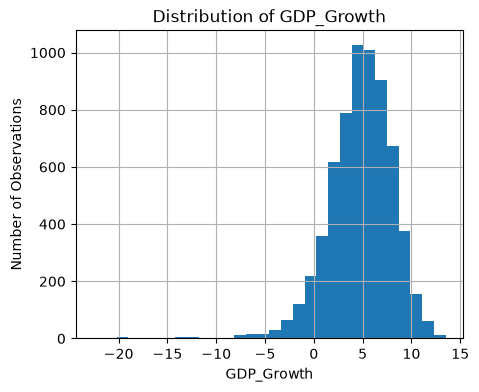

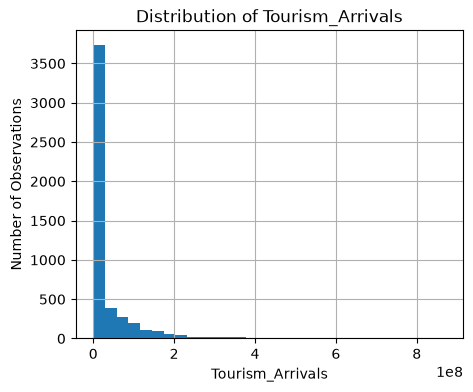

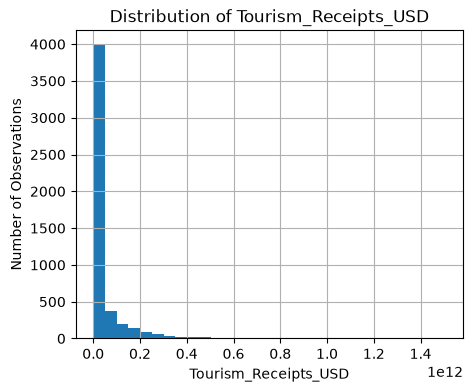

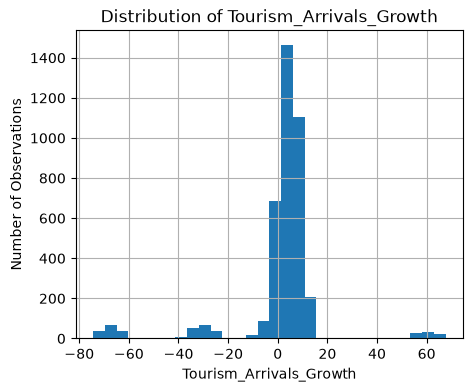

In [58]:
eda_variables = [
    'GDP_Growth',
    'Tourism_Arrivals',
    'Tourism_Receipts_USD',
    'Tourism_Arrivals_Growth'
]

for variable in eda_variables:
    plt.figure(figsize=(5, 4))
    df[variable].hist(bins=30)
    plt.title(f'Distribution of {variable}')
    plt.xlabel(variable)
    plt.ylabel('Number of Observations')
    plt.show()

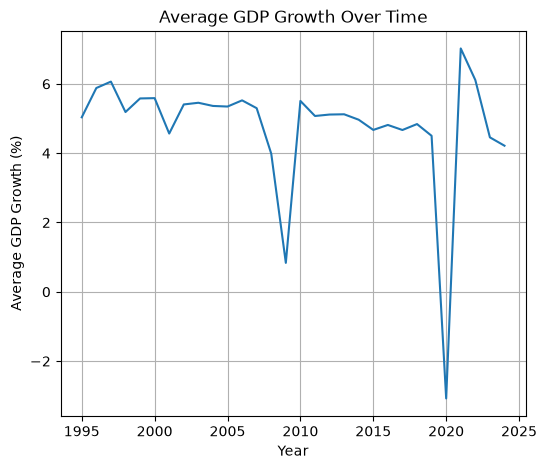

In [60]:
yearly_gdp = df.groupby('Year')['GDP_Growth'].mean()

plt.figure(figsize=(6, 5))
plt.plot(yearly_gdp.index, yearly_gdp.values)

plt.title('Average GDP Growth Over Time')
plt.xlabel('Year')
plt.ylabel('Average GDP Growth (%)')
plt.grid(True)
plt.show()

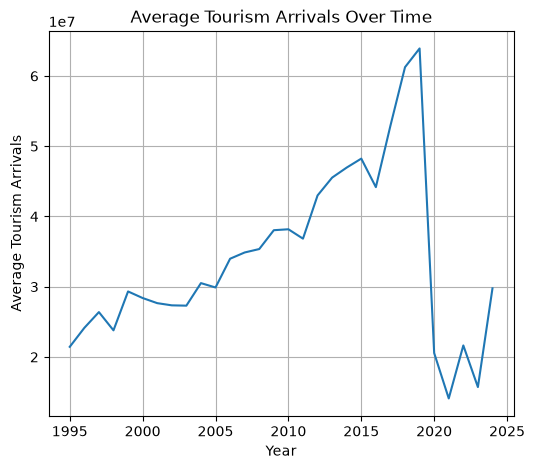

In [61]:
yearly_arrivals = df.groupby('Year')['Tourism_Arrivals'].mean()

plt.figure(figsize=(6, 5))
plt.plot(yearly_arrivals.index, yearly_arrivals.values)

plt.title('Average Tourism Arrivals Over Time')
plt.xlabel('Year')
plt.ylabel('Average Tourism Arrivals')
plt.grid(True)
plt.show()

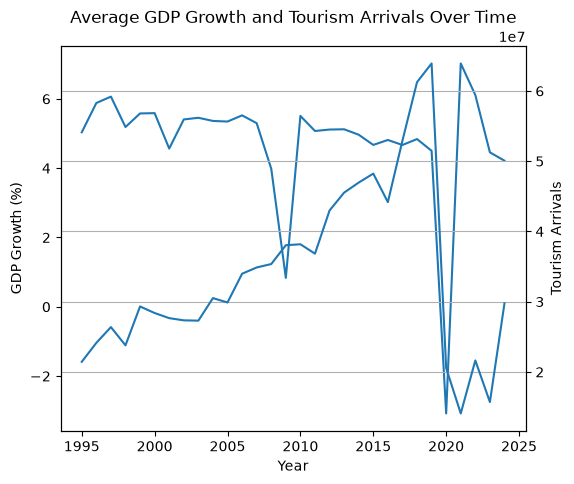

In [62]:
yearly_data = df.groupby('Year').agg({
    'GDP_Growth': 'mean',
    'Tourism_Arrivals': 'mean'
})

fig, ax1 = plt.subplots(figsize=(6,5))

ax1.plot(
    yearly_data.index,
    yearly_data['GDP_Growth'],
    label='GDP Growth'
)

ax1.set_xlabel('Year')
ax1.set_ylabel('GDP Growth (%)')

ax2 = ax1.twinx()

ax2.plot(
    yearly_data.index,
    yearly_data['Tourism_Arrivals'],
    label='Tourism Arrivals'
)

ax2.set_ylabel('Tourism Arrivals')

plt.title('Average GDP Growth and Tourism Arrivals Over Time')
plt.grid(True)
plt.show()

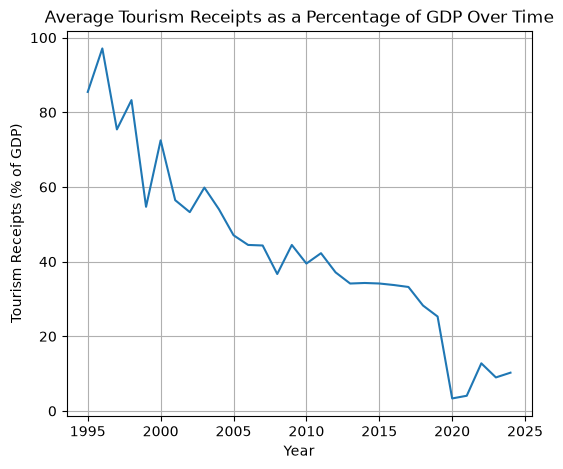

In [63]:
yearly_tourism_share = df.groupby('Year')['Tourism_Receipts_pct_GDP'].mean()

plt.figure(figsize=(6, 5))
plt.plot(
    yearly_tourism_share.index,
    yearly_tourism_share.values
)

plt.title('Average Tourism Receipts as a Percentage of GDP Over Time')
plt.xlabel('Year')
plt.ylabel('Tourism Receipts (% of GDP)')
plt.grid(True)
plt.show()

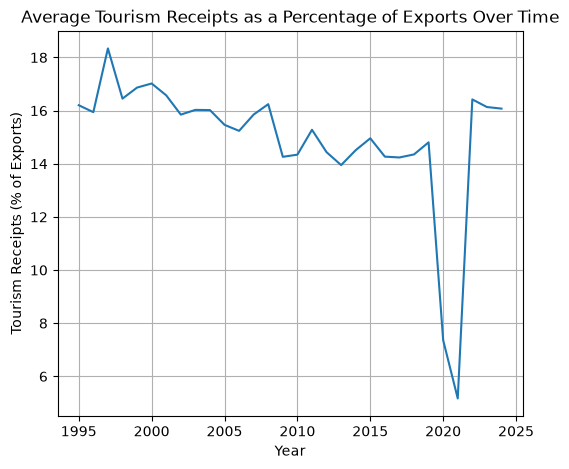

In [64]:
yearly_tourism_exports = df.groupby('Year')['Tourism_Receipts_pct_Exports'].mean()

plt.figure(figsize=(6, 5))
plt.plot(
    yearly_tourism_exports.index,
    yearly_tourism_exports.values
)

plt.title('Average Tourism Receipts as a Percentage of Exports Over Time')
plt.xlabel('Year')
plt.ylabel('Tourism Receipts (% of Exports)')
plt.grid(True)
plt.show()

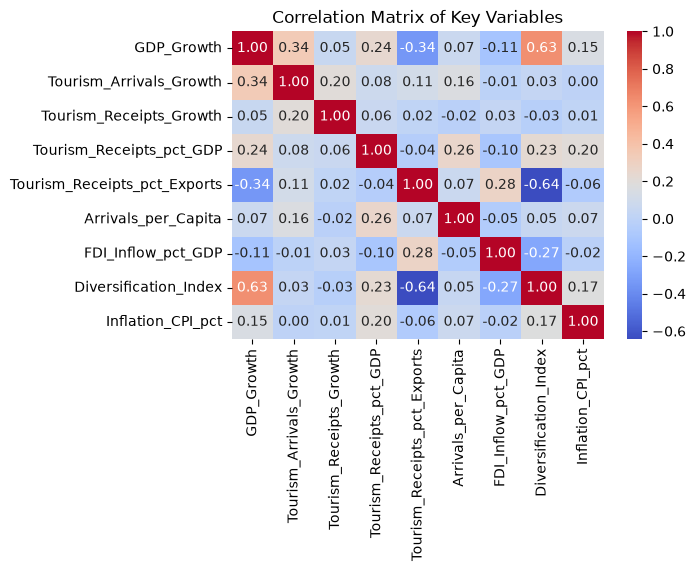

In [68]:
correlation_variables = [
    'GDP_Growth',
    'Tourism_Arrivals_Growth',
    'Tourism_Receipts_Growth',
    'Tourism_Receipts_pct_GDP',
    'Tourism_Receipts_pct_Exports',
    'Arrivals_per_Capita',
    'FDI_Inflow_pct_GDP',
    'Diversification_Index',
    'Inflation_CPI_pct'
]

correlation_matrix = df[correlation_variables].corr()
plt.figure(figsize=(6, 4))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix of Key Variables')
plt.show()

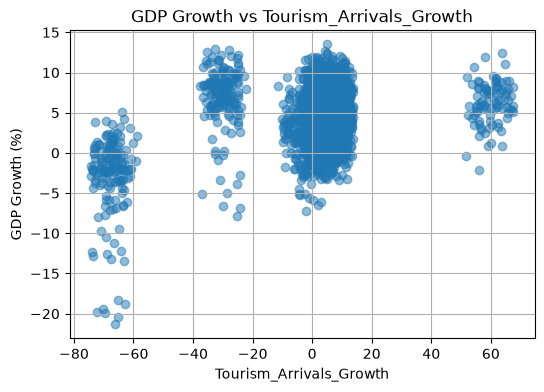

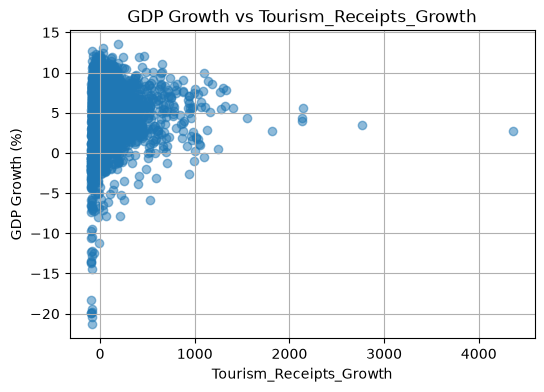

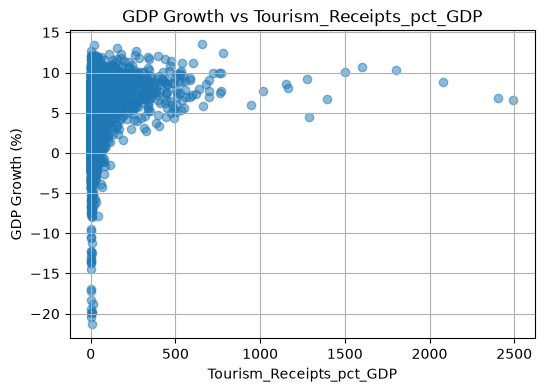

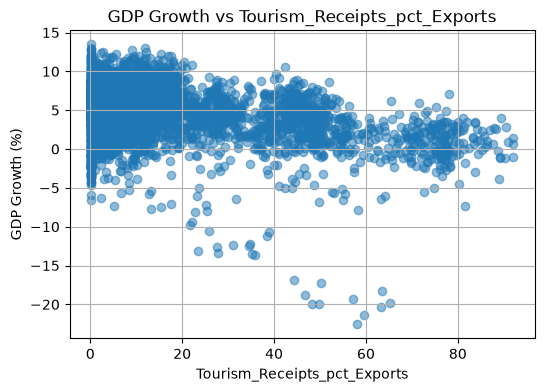

In [70]:
scatter_variables = [
    'Tourism_Arrivals_Growth',
    'Tourism_Receipts_Growth',
    'Tourism_Receipts_pct_GDP',
    'Tourism_Receipts_pct_Exports'
]

for variable in scatter_variables:
    plt.figure(figsize=(6, 4))
    plt.scatter(df[variable], df['GDP_Growth'], alpha=0.5)
    
    plt.title(f'GDP Growth vs {variable}')
    plt.xlabel(variable)
    plt.ylabel('GDP Growth (%)')
    plt.grid(True)
    plt.show()

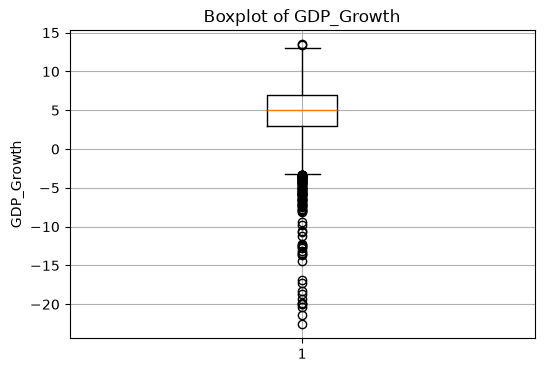

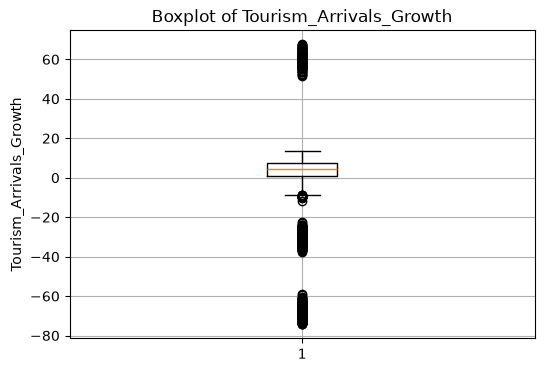

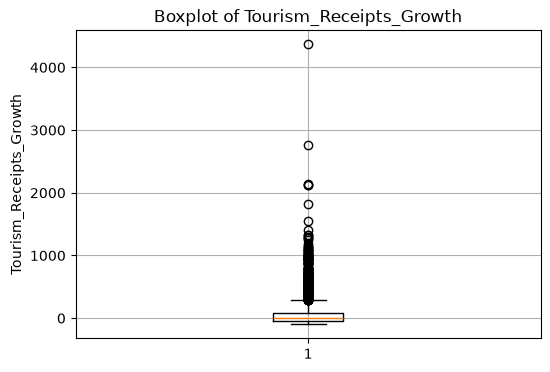

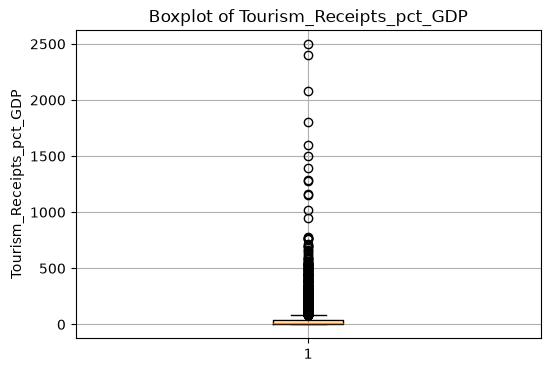

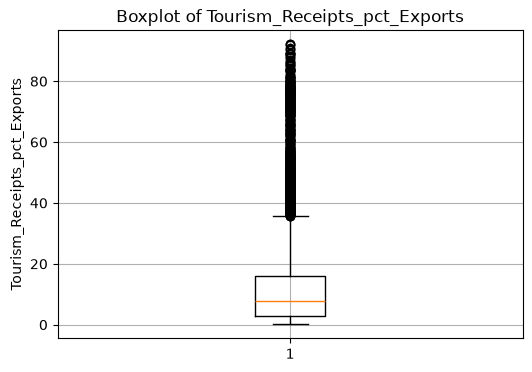

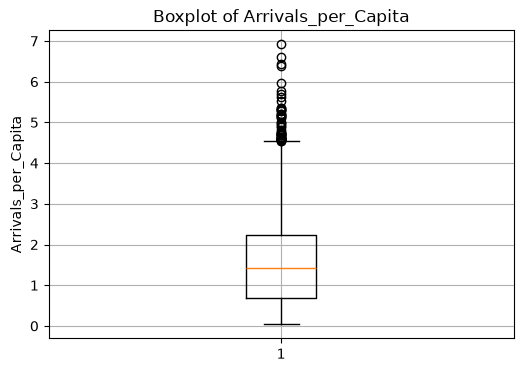

In [75]:
outlier_variables = [
    'GDP_Growth',
    'Tourism_Arrivals_Growth',
    'Tourism_Receipts_Growth',
    'Tourism_Receipts_pct_GDP',
    'Tourism_Receipts_pct_Exports',
    'Arrivals_per_Capita'
]

for variable in outlier_variables:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[variable].dropna())
    
    plt.title(f'Boxplot of {variable}')
    plt.ylabel(variable)
    plt.grid(True)
    plt.show()

In [76]:
for variable in outlier_variables:
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[variable] < lower_bound) |
        (df[variable] > upper_bound)
    ][variable].dropna()

    print(variable)
    print("Number of outliers:", len(outliers))
    print("Percentage of observations:", round(len(outliers) / df[variable].notna().sum() * 100, 2))
    print()

GDP_Growth
Number of outliers: 101
Percentage of observations: 1.56

Tourism_Arrivals_Growth
Number of outliers: 410
Percentage of observations: 10.35

Tourism_Receipts_Growth
Number of outliers: 346
Percentage of observations: 8.74

Tourism_Receipts_pct_GDP
Number of outliers: 569
Percentage of observations: 11.35

Tourism_Receipts_pct_Exports
Number of outliers: 715
Percentage of observations: 14.23

Arrivals_per_Capita
Number of outliers: 53
Percentage of observations: 1.05



In [77]:
for variable in ['Tourism_Arrivals_Growth', 'Tourism_Receipts_Growth']:
    
    Q1 = df[variable].quantile(0.25)
    Q3 = df[variable].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_data = df[
        (df[variable] < lower_bound) |
        (df[variable] > upper_bound)
    ][['Country', 'Year', variable]]

    print("\n", variable)
    print("Lower bound:", lower_bound)
    print("Upper bound:", upper_bound)
    print("Number of outliers:", len(outlier_data))
    print(outlier_data.head(10))


 Tourism_Arrivals_Growth
Lower bound: -8.720762316067754
Upper bound: 16.910035349616724
Number of outliers: 410
            Country  Year  Tourism_Arrivals_Growth
25      Afghanistan  2020               -66.537902
26      Afghanistan  2021               -28.625751
56          Albania  2021               -28.358060
85          Algeria  2020               -74.016145
86          Algeria  2021               -32.342585
87          Algeria  2022                62.225750
115  American Samoa  2020               -60.972163
116  American Samoa  2021               -29.604956
145         Andorra  2020               -64.056355
146         Andorra  2021               -24.389641

 Tourism_Receipts_Growth
Lower bound: -247.10961864862264
Upper bound: 292.28288809345423
Number of outliers: 346
                 Country  Year  Tourism_Receipts_Growth
63               Algeria  1998               301.710840
67               Algeria  2002               377.079271
82               Algeria  2017            

In [78]:
maldives = df[df['Country'] == 'Maldives']

maldives[['Year',
          'GDP_Growth',
          'Tourism_Arrivals_Growth',
          'Tourism_Receipts_pct_GDP',
          'Tourism_Receipts_pct_Exports',
          'Diversification_Index']].head()

,Year,GDP_Growth,Tourism_Arrivals_Growth,Tourism_Receipts_pct_GDP,Tourism_Receipts_pct_Exports,Diversification_Index
3630,1995,-1.325,NaN,8.482,NaN,0.216333
3631,1996,0.116,NaN,19.082,44.437,0.386090
3632,1997,0.725,13.195780,25.048,NaN,0.339698
3633,1998,0.222,7.009480,23.517,NaN,0.421697
3634,1999,3.002,8.428695,20.340,41.853,0.278194


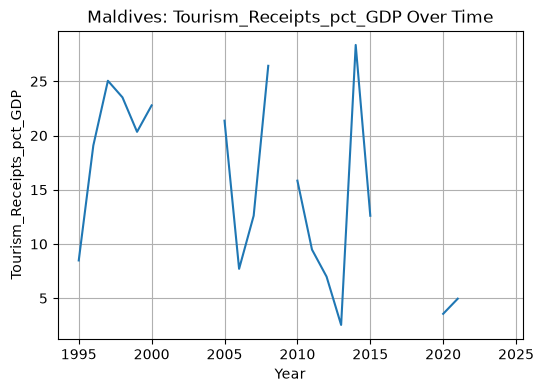

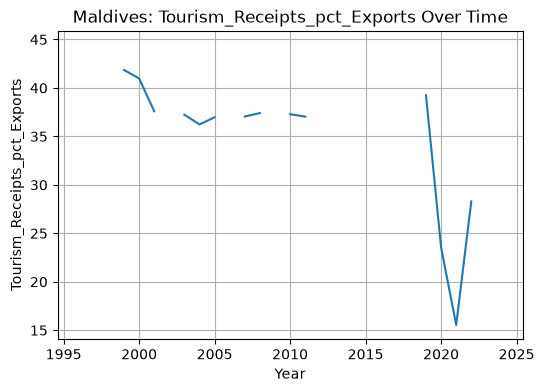

In [83]:
maldives_variables = [
    'Tourism_Receipts_pct_GDP',
    'Tourism_Receipts_pct_Exports'
]

for variable in maldives_variables:
    plt.figure(figsize=(6, 4))
    
    plt.plot(
        maldives['Year'],
        maldives[variable]
    )
    
    plt.title(f'Maldives: {variable} Over Time')
    plt.xlabel('Year')
    plt.ylabel(variable)
    plt.grid(True)
    plt.show()

### Maldives vs peers

Maldives ranks 6th of 15 on tourism dependence (9.88% vs peer median 5.79%) and 11th of 15 on diversification (0.38 vs peer median 0.53). Tourism dependence peaked in the mid-2000s and has since declined, while diversification has remained persistently low across three decades — well below peers like Mauritius (≈0.70) and Cabo Verde (≈0.57). This high-tourism, low-diversification profile provides the basis for the scenario analysis.

In [124]:
# Filter the dataset to the 15 core island economies for peer comparison
# Is_Core_Island_Sample == 1 identifies the countries that are the focus of our analysis
core_islands = df[df['Is_Core_Island_Sample'] == 1].copy()

print("Number of core island countries:", core_islands['Country'].nunique())
print("Countries:", sorted(core_islands['Country'].unique()))

Number of core island countries: 15
Countries: ['Bahamas, The', 'Barbados', 'Cabo Verde', 'Dominica', 'Fiji', 'Jamaica', 'Maldives', 'Mauritius', 'Samoa', 'Sao Tome and Principe', 'Seychelles', 'Solomon Islands', 'St. Lucia', 'Tonga', 'Vanuatu']


In [125]:
# For each core island country, get the most recent year where key variables are available
# This gives a fair "current profile" snapshot for comparison

# Variables we want to compare Maldives against peers on
comparison_vars = [
    'Tourism_Receipts_pct_GDP',
    'Diversification_Index',
    'Services_pct_GDP',
    'GDP_Growth'
]

# For each country, take the latest year where Tourism_Receipts_pct_GDP is available
# (Tourism data has more gaps, so we anchor on that)
latest_per_country = (
    core_islands.dropna(subset=['Tourism_Receipts_pct_GDP'])
    .sort_values('Year')
    .groupby('Country')
    .tail(1)
    [['Country', 'Year'] + comparison_vars]
    .reset_index(drop=True)
)

# Sort the table by tourism dependence (highest first) so Maldives' position is visible
latest_per_country = latest_per_country.sort_values(
    'Tourism_Receipts_pct_GDP', ascending=False
).reset_index(drop=True)

print("Latest-year profile of the 15 core island economies:")
print("(Sorted by Tourism_Receipts_pct_GDP, highest first)")
display(latest_per_country.round(2))

Latest-year profile of the 15 core island economies:
(Sorted by Tourism_Receipts_pct_GDP, highest first)


,Country,Year,Tourism_Receipts_pct_GDP,Diversification_Index,Services_pct_GDP,GDP_Growth
0,Seychelles,2024,22.88,0.32,86.78,-0.49
1,Vanuatu,2022,18.83,0.74,62.53,9.45
2,Cabo Verde,2024,14.82,0.57,74.11,5.31
3,Dominica,2022,12.64,0.53,76.11,5.05
4,Samoa,2024,12.29,0.66,68.47,4.23
5,Maldives,2024,9.88,0.38,83.96,1.48
6,Tonga,2022,7.54,0.68,65.92,4.71
7,Solomon Islands,2024,5.79,0.65,69.33,3.46
8,St. Lucia,2021,5.57,0.23,90.70,-7.86
9,"Bahamas, The",2022,3.99,0.38,84.19,3.23


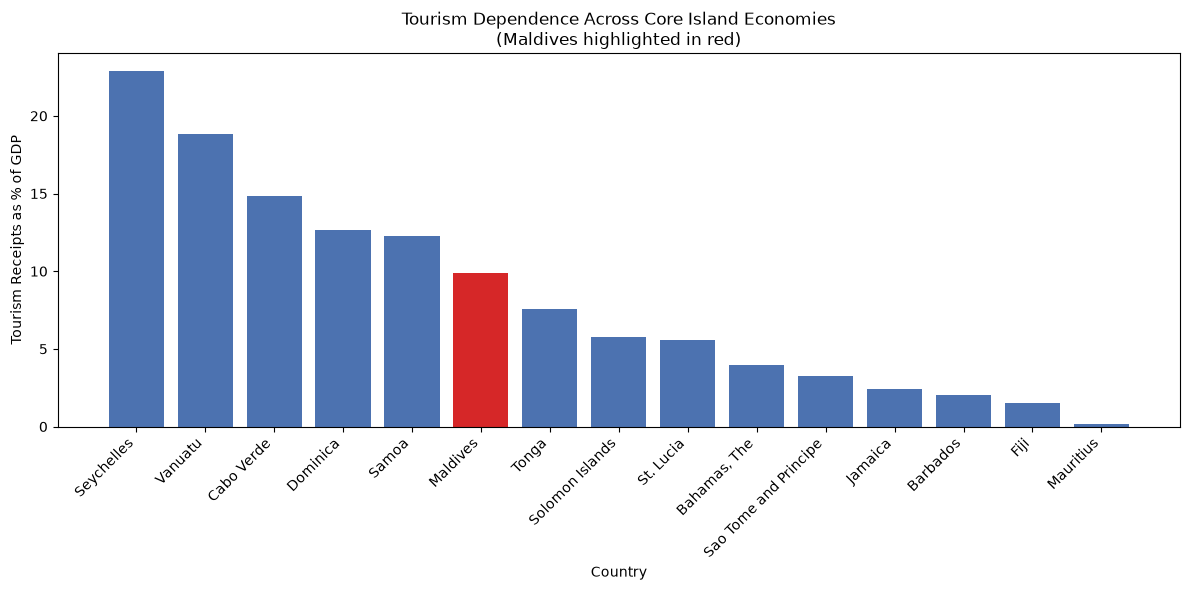

In [126]:
# Bar chart showing where Maldives ranks on tourism dependence vs peer islands
# Maldives is highlighted in a different colour so it stands out

plt.figure(figsize=(12, 6))

# Colour Maldives differently to make it visually obvious
colors = ['#d62728' if country == 'Maldives' else '#4c72b0'
          for country in latest_per_country['Country']]

plt.bar(
    latest_per_country['Country'],
    latest_per_country['Tourism_Receipts_pct_GDP'],
    color=colors
)

plt.title('Tourism Dependence Across Core Island Economies\n(Maldives highlighted in red)')
plt.xlabel('Country')
plt.ylabel('Tourism Receipts as % of GDP')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

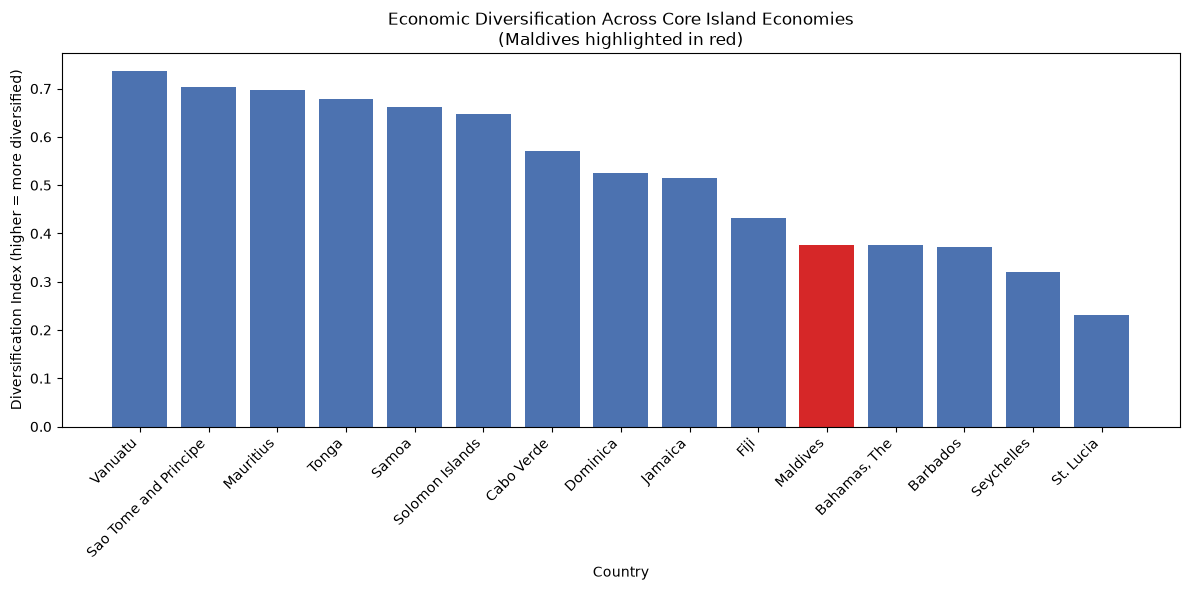

In [127]:
# Same chart but for diversification — Maldives should look different on this dimension too
# Higher Diversification_Index = more diversified economy

# Sort by diversification for this chart
div_sorted = latest_per_country.sort_values('Diversification_Index', ascending=False)

plt.figure(figsize=(12, 6))

colors = ['#d62728' if country == 'Maldives' else '#4c72b0'
          for country in div_sorted['Country']]

plt.bar(
    div_sorted['Country'],
    div_sorted['Diversification_Index'],
    color=colors
)

plt.title('Economic Diversification Across Core Island Economies\n(Maldives highlighted in red)')
plt.xlabel('Country')
plt.ylabel('Diversification Index (higher = more diversified)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

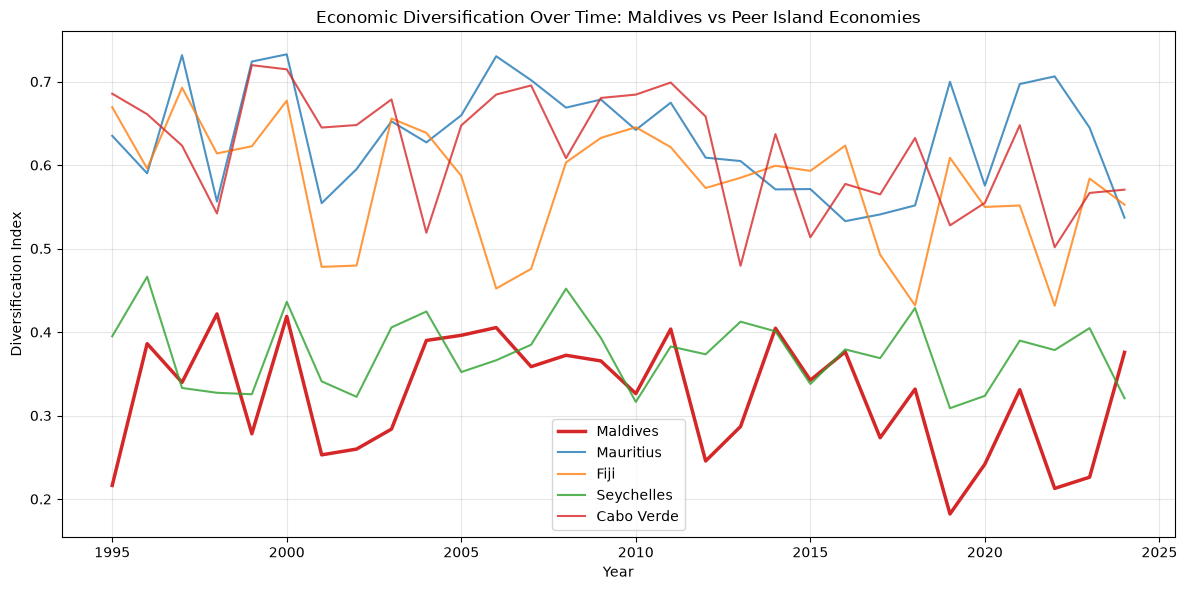

In [128]:
# Line chart showing how Maldives' diversification has changed over time
# vs 4 selected peer economies for context

# Pick Maldives plus 4 peers commonly used as comparators in island economics research
peer_countries = ['Maldives', 'Mauritius', 'Fiji', 'Seychelles', 'Cabo Verde']

plt.figure(figsize=(12, 6))

for country in peer_countries:
    country_data = core_islands[core_islands['Country'] == country].sort_values('Year')
    
    # Highlight Maldives with a thicker, red line
    if country == 'Maldives':
        plt.plot(country_data['Year'], country_data['Diversification_Index'],
                 label=country, color='#d62728', linewidth=2.5)
    else:
        plt.plot(country_data['Year'], country_data['Diversification_Index'],
                 label=country, linewidth=1.5, alpha=0.8)

plt.title('Economic Diversification Over Time: Maldives vs Peer Island Economies')
plt.xlabel('Year')
plt.ylabel('Diversification Index')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

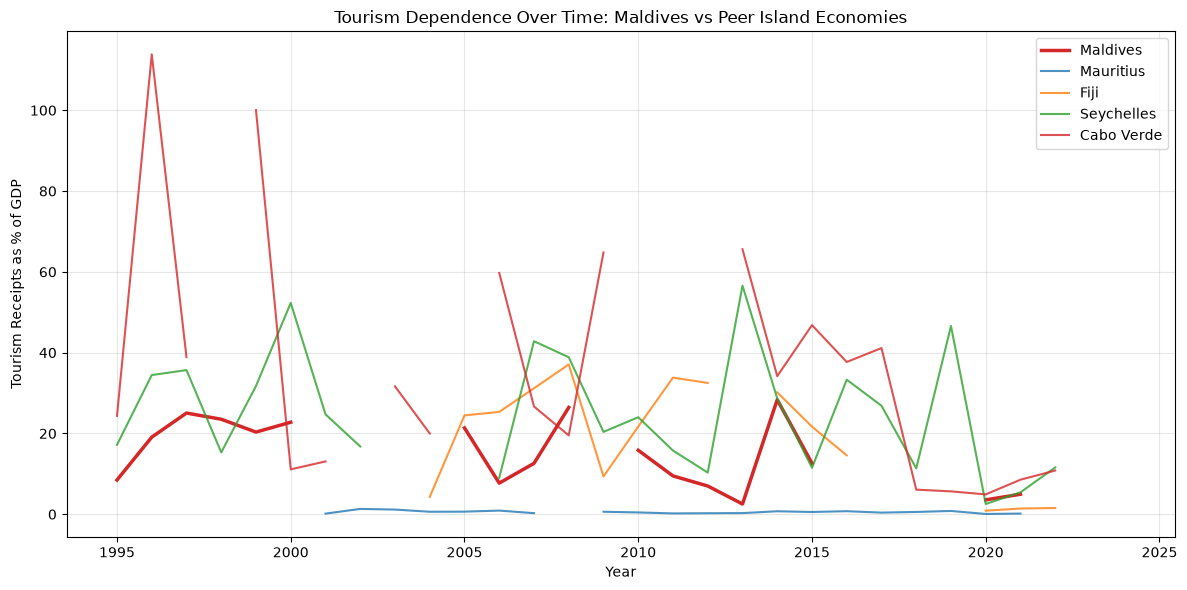

In [129]:
# Same time-series comparison but for tourism dependence
# Shows whether Maldives has always been an outlier or if the gap has grown

plt.figure(figsize=(12, 6))

for country in peer_countries:
    country_data = core_islands[core_islands['Country'] == country].sort_values('Year')
    
    if country == 'Maldives':
        plt.plot(country_data['Year'], country_data['Tourism_Receipts_pct_GDP'],
                 label=country, color='#d62728', linewidth=2.5)
    else:
        plt.plot(country_data['Year'], country_data['Tourism_Receipts_pct_GDP'],
                 label=country, linewidth=1.5, alpha=0.8)

plt.title('Tourism Dependence Over Time: Maldives vs Peer Island Economies')
plt.xlabel('Year')
plt.ylabel('Tourism Receipts as % of GDP')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [130]:
# Print the exact numbers needed for the written finding
mdv = latest_per_country[latest_per_country['Country'] == 'Maldives'].iloc[0]

# Tourism dependence
tourism_rank = latest_per_country.reset_index(drop=True).index[
    latest_per_country['Country'] == 'Maldives'
][0] + 1
tourism_median = latest_per_country['Tourism_Receipts_pct_GDP'].median()

# Diversification
div_rank = div_sorted.reset_index(drop=True).index[
    div_sorted['Country'] == 'Maldives'
][0] + 1
div_median = latest_per_country['Diversification_Index'].median()

print(f"Maldives tourism dependence: {mdv['Tourism_Receipts_pct_GDP']:.2f}%")
print(f"Peer median tourism dependence: {tourism_median:.2f}%")
print(f"Maldives tourism rank: {tourism_rank} of 15")
print()
print(f"Maldives diversification index: {mdv['Diversification_Index']:.2f}")
print(f"Peer median diversification: {div_median:.2f}")
print(f"Maldives diversification rank: {div_rank} of 15")

Maldives tourism dependence: 9.88%
Peer median tourism dependence: 5.79%
Maldives tourism rank: 6 of 15

Maldives diversification index: 0.38
Peer median diversification: 0.53
Maldives diversification rank: 11 of 15


### Key finding — Maldives vs peers

Among the 15 core island economies:

- **Tourism dependence:** Maldives ranks 6th out of 15 on Tourism Receipts % GDP, with a value of 9.88% vs the peer median of 5.79%. [Adjective — e.g., "significantly higher than", "in line with", "lower than"] its regional peers.
- **Diversification:** Maldives has a Diversification Index of 0.38, ranking 11th out of 15. This is [above/below] the peer median of 0.53.
- **Time trend:** Maldives' tourism dependence has [risen/fallen/stayed flat] over the past decade, while peer economies like Mauritius and Cabo Verde have [pattern].

This positioning matters for our analysis: Maldives sits in the upper third of the sample on tourism dependence and the lower third on diversification. This combination — high reliance on tourism paired with a narrow economic base — is exactly the profile the model uses to predict future GDP growth. The scenario analysis will explore what predicted growth looks like if Maldives moved closer to the diversification profile of peers like Mauritius (Diversification Index ≈ 0.70) or Cabo Verde (≈ 0.57).

In [84]:
key_variables = [
    'GDP_Growth',
    'Tourism_Arrivals_Growth',
    'Tourism_Receipts_Growth',
    'Tourism_Receipts_pct_GDP',
    'Tourism_Receipts_pct_Exports',
    'Arrivals_per_Capita',
    'FDI_Inflow_pct_GDP',
    'Diversification_Index',
    'Inflation_CPI_pct'
]

for variable in key_variables:
    missing = df[variable].isna().sum()
    percentage = df[variable].isna().mean() * 100
    
    print(variable)
    print("Missing:", missing)
    print("Percentage missing:", round(percentage, 2))
    print()

GDP_Growth
Missing: 0
Percentage missing: 0.0

Tourism_Arrivals_Growth
Missing: 2517
Percentage missing: 38.84

Tourism_Receipts_Growth
Missing: 2523
Percentage missing: 38.94

Tourism_Receipts_pct_GDP
Missing: 1465
Percentage missing: 22.61

Tourism_Receipts_pct_Exports
Missing: 1454
Percentage missing: 22.44

Arrivals_per_Capita
Missing: 1453
Percentage missing: 22.42

FDI_Inflow_pct_GDP
Missing: 0
Percentage missing: 0.0

Diversification_Index
Missing: 0
Percentage missing: 0.0

Inflation_CPI_pct
Missing: 0
Percentage missing: 0.0



In [85]:
missing_by_country = df.groupby('Country')[
    ['Tourism_Arrivals_Growth', 'Tourism_Receipts_Growth']
].apply(lambda x: x.isna().sum())

missing_by_country.sort_values(
    'Tourism_Arrivals_Growth',
    ascending=False
).head(15)

,Tourism_Arrivals_Growth,Tourism_Receipts_Growth
Country,,
Turks and Caicos Islands,26,16
Guinea,25,17
Timor-Leste,23,12
French Polynesia,23,16
Samoa,22,16
Panama,22,17
Germany,22,18
Ukraine,22,19
Colombia,21,14


In [86]:
# This step shows all variables currently available in the dataset.

print("Number of variables:", len(df.columns))
for i, col in enumerate(df.columns, start=1):
    print(f"{i}. {col}")

Number of variables: 53
1. Country_Code
2. Country
3. Region
4. Income_Group
5. Year
6. Data_Type
7. Is_SIDS
8. Is_Core_Island_Sample
9. GDP_Growth
10. GDP_per_Capita_USD
11. GDP_per_Capita_Growth
12. GDP_Current_USD
13. Population
14. Land_Area_sq_km
15. Agriculture_pct_GDP
16. Industry_pct_GDP
17. Manufacturing_pct_GDP
18. Services_pct_GDP
19. Exports_pct_GDP
20. Imports_pct_GDP
21. Trade_pct_GDP
22. FDI_Inflow_pct_GDP
23. Current_Account_pct_GDP
24. Reserves_Months_Imports
25. Inflation_CPI_pct
26. Unemployment_pct
27. Public_Debt_pct_GDP
28. Govt_Expenditure_pct_GDP
29. Tourism_Arrivals
30. Tourism_Receipts_USD
31. Tourism_Receipts_pct_Exports
32. Tourism_Expenditure_USD
33. Internet_Users_pct
34. Mobile_Subs_per_100
35. Urban_Population_pct
36. Secondary_Enrolment_Gross
37. Diversification_Index
38. Next_Year_GDP_Growth
39. Tourism_Arrivals_Growth
40. Tourism_Receipts_Growth
41. Tourism_Receipts_pct_GDP
42. Arrivals_per_Capita
43. Tourism_Shock_Flag
44. Tourism_Dependent_Flag
45. 

In [87]:
# This step checks the dataset size, variable types, and first few observations.

print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nFirst five observations:")
display(df.head())

Dataset shape: (6480, 53)

Data types:


Country_Code                        str
Country                             str
Region                              str
Income_Group                        str
Year                              int64
Data_Type                           str
Is_SIDS                           int64
Is_Core_Island_Sample             int64
GDP_Growth                      float64
GDP_per_Capita_USD              float64
GDP_per_Capita_Growth           float64
GDP_Current_USD                   int64
Population                        int64
Land_Area_sq_km                 float64
Agriculture_pct_GDP             float64
Industry_pct_GDP                float64
Manufacturing_pct_GDP           float64
Services_pct_GDP                float64
Exports_pct_GDP                 float64
Imports_pct_GDP                 float64
Trade_pct_GDP                   float64
FDI_Inflow_pct_GDP              float64
Current_Account_pct_GDP         float64
Reserves_Months_Imports         float64
Inflation_CPI_pct               float64



First five observations:


,Country_Code,Country,Region,Income_Group,Year,Data_Type,Is_SIDS,Is_Core_Island_Sample,GDP_Growth,GDP_per_Capita_USD,...,Tourism_Dependent_Flag,GDP_Growth_lag1,Tourism_Arrivals_Growth_lag1,FDI_Inflow_pct_GDP_lag1,Diversification_Index_lag1,Inflation_CPI_pct_lag1,GDP_Growth_3yr_MA,GDP_Growth_Volatility_5yr,Global_Shock_Year,COVID_Period
0,AFG,Afghanistan,South Asia,Low income,1995,SYNTHETIC_PROTOTYPE,0,0,8.608,538.97,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,AFG,Afghanistan,South Asia,Low income,1996,SYNTHETIC_PROTOTYPE,0,0,6.809,584.99,...,0.0,8.608,NaN,2.043,0.846989,0.533,7.709,NaN,0,0
2,AFG,Afghanistan,South Asia,Low income,1997,SYNTHETIC_PROTOTYPE,0,0,5.569,630.83,...,0.0,6.809,1.864475,3.017,0.826035,10.265,6.995,1.528,0,0
3,AFG,Afghanistan,South Asia,Low income,1998,SYNTHETIC_PROTOTYPE,0,0,6.157,684.78,...,0.0,5.569,10.095488,4.454,0.779671,5.420,6.178,1.316,0,0
4,AFG,Afghanistan,South Asia,Low income,1999,SYNTHETIC_PROTOTYPE,0,0,8.721,744.97,...,NaN,6.157,3.676084,3.352,0.765478,4.879,6.816,1.431,0,0


In [90]:
# This step confirms the variables that identify each country and year in the panel.

print("Country variable:", "Country")
print("Year variable:", "Year")

print("\nNumber of countries:", df["Country"].nunique())
print("Number of years:", df["Year"].nunique())

print("\nYear range:", df["Year"].min(), "to", df["Year"].max())

Country variable: Country
Year variable: Year

Number of countries: 216
Number of years: 30

Year range: 1995 to 2024


In [91]:
# This step shows how many observations are available for each variable before modelling.

variable_summary = pd.DataFrame({
    "Variable": df.columns,
    "Non_Missing": df.notna().sum().values,
    "Missing": df.isna().sum().values,
    "Missing_Percent": (df.isna().mean() * 100).round(2).values
})

display(variable_summary)

,Variable,Non_Missing,Missing,Missing_Percent
0,Country_Code,6480,0,0.00
1,Country,6480,0,0.00
2,Region,6480,0,0.00
3,Income_Group,6480,0,0.00
4,Year,6480,0,0.00
5,Data_Type,6480,0,0.00
6,Is_SIDS,6480,0,0.00
7,Is_Core_Island_Sample,6480,0,0.00
8,GDP_Growth,6480,0,0.00
9,GDP_per_Capita_USD,6480,0,0.00


In [92]:
# This step defines the main variables that will be used in the econometric analysis.

dependent_variable = "Next_Year_GDP_Growth"

tourism_variables = [
    "Tourism_Arrivals_Growth",
    "Tourism_Receipts_Growth",
    "Tourism_Receipts_pct_GDP",
    "Arrivals_per_Capita"
]

key_structural_variable = "Diversification_Index"

control_variables = [
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP",
    "Services_pct_GDP"
]

robustness_variables = [
    "GDP_Growth_3yr_MA",
    "GDP_Growth_Volatility_5yr",
    "Tourism_Dependent_Flag",
    "Tourism_Shock_Flag",
    "COVID_Period",
    "Global_Shock_Year"
]

print("Dependent variable:", dependent_variable)
print("Tourism variables:", tourism_variables)
print("Key structural variable:", key_structural_variable)
print("Control variables:", control_variables)
print("Robustness variables:", robustness_variables)

Dependent variable: Next_Year_GDP_Growth
Tourism variables: ['Tourism_Arrivals_Growth', 'Tourism_Receipts_Growth', 'Tourism_Receipts_pct_GDP', 'Arrivals_per_Capita']
Key structural variable: Diversification_Index
Control variables: ['GDP_Growth_lag1', 'FDI_Inflow_pct_GDP', 'Inflation_CPI_pct', 'Trade_pct_GDP', 'Services_pct_GDP']
Robustness variables: ['GDP_Growth_3yr_MA', 'GDP_Growth_Volatility_5yr', 'Tourism_Dependent_Flag', 'Tourism_Shock_Flag', 'COVID_Period', 'Global_Shock_Year']


In [93]:
# This step examines missing values in the variables selected for the econometric analysis.

model_variables = (
    [dependent_variable]
    + tourism_variables
    + [key_structural_variable]
    + control_variables
    + robustness_variables
)

missing_summary = pd.DataFrame({
    "Variable": model_variables,
    "Missing_Count": df[model_variables].isna().sum().values,
    "Missing_Percent": (df[model_variables].isna().mean() * 100).round(2).values
})

display(
    missing_summary.sort_values(
        "Missing_Percent",
        ascending=False
    )
)

,Variable,Missing_Count,Missing_Percent
2,Tourism_Receipts_Growth,2523,38.94
14,Tourism_Shock_Flag,2517,38.84
1,Tourism_Arrivals_Growth,2517,38.84
3,Tourism_Receipts_pct_GDP,1465,22.61
13,Tourism_Dependent_Flag,1454,22.44
4,Arrivals_per_Capita,1453,22.42
12,GDP_Growth_Volatility_5yr,432,6.67
0,Next_Year_GDP_Growth,216,3.33
6,GDP_Growth_lag1,216,3.33
11,GDP_Growth_3yr_MA,216,3.33


In [ ]:
# This step creates a clean dataset by removing observations missing the outcome variable.

df_model = df.dropna(subset=[dependent_variable]).copy()
print("Original observations:", len(df))
print("Observations after removing missing outcome values:", len(df_model))
print("Observations removed:", len(df) - len(df_model))

Original observations: 6480
Observations after removing missing outcome values: 6264
Observations removed: 216


In [96]:
# This step checks the scales and distributions of the main continuous variables before modelling.

scale_variables = (
    [dependent_variable]
    + tourism_variables
    + [key_structural_variable]
    + control_variables
)

scale_summary = df_model[scale_variables].describe().T[
    ["count", "mean", "std", "min", "50%", "max"]
]

display(scale_summary.round(2))

,count,mean,std,min,50%,max
Next_Year_GDP_Growth,6264.0,4.76,3.35,-22.60,5.03,13.49
Tourism_Arrivals_Growth,3922.0,1.63,17.97,-74.35,4.33,67.59
Tourism_Receipts_Growth,3921.0,65.14,212.78,-98.76,3.49,4366.48
Tourism_Receipts_pct_GDP,4925.0,44.11,116.20,0.01,11.91,2495.75
Arrivals_per_Capita,4931.0,1.58,1.05,0.04,1.45,6.92
Diversification_Index,6264.0,0.69,0.16,0.12,0.72,0.94
GDP_Growth_lag1,6048.0,4.80,3.38,-22.60,5.07,13.49
FDI_Inflow_pct_GDP,6264.0,4.42,3.89,-4.00,3.45,30.63
Inflation_CPI_pct,6264.0,5.83,4.50,-3.00,5.59,25.47
Trade_pct_GDP,6264.0,76.41,32.13,9.00,76.01,207.02


The main variables are retained in their original economic units. Standardization and normalization are not applied at this stage because the variables are already expressed as growth rates, percentages, ratios, or indices. Transformations will be considered later if required by model diagnostics.


In [98]:
# This step checks the categorical variables that are present in the dataset.

categorical_variables = df_model.select_dtypes(include=["object", "category"]).columns.tolist()

print("Categorical variables:", categorical_variables)

Categorical variables: ['Country_Code', 'Country', 'Region', 'Income_Group', 'Data_Type']


In [99]:
# This step checks correlations among the main explanatory variables to identify possible multicollinearity.

feature_variables = (
    tourism_variables
    + [key_structural_variable]
    + control_variables
)

correlation_matrix = df_model[feature_variables].corr()

display(correlation_matrix.round(2))

,Tourism_Arrivals_Growth,Tourism_Receipts_Growth,Tourism_Receipts_pct_GDP,Arrivals_per_Capita,Diversification_Index,GDP_Growth_lag1,FDI_Inflow_pct_GDP,Inflation_CPI_pct,Trade_pct_GDP,Services_pct_GDP
Tourism_Arrivals_Growth,1.00,0.20,0.08,0.16,0.03,0.23,-0.01,0.00,-0.01,-0.04
Tourism_Receipts_Growth,0.20,1.00,0.06,-0.02,-0.03,-0.03,0.03,0.01,0.03,0.03
Tourism_Receipts_pct_GDP,0.08,0.06,1.00,0.26,0.23,0.26,-0.10,0.21,-0.01,-0.31
Arrivals_per_Capita,0.16,-0.02,0.26,1.00,0.04,0.11,-0.05,0.07,0.00,-0.05
Diversification_Index,0.03,-0.03,0.23,0.04,1.00,0.57,-0.27,0.17,-0.12,-0.96
GDP_Growth_lag1,0.23,-0.03,0.26,0.11,0.57,1.00,-0.15,0.13,-0.08,-0.58
FDI_Inflow_pct_GDP,-0.01,0.03,-0.10,-0.05,-0.27,-0.15,1.00,-0.02,0.07,0.26
Inflation_CPI_pct,0.00,0.01,0.21,0.07,0.17,0.13,-0.02,1.00,-0.03,-0.24
Trade_pct_GDP,-0.01,0.03,-0.01,0.00,-0.12,-0.08,0.07,-0.03,1.00,0.12
Services_pct_GDP,-0.04,0.03,-0.31,-0.05,-0.96,-0.58,0.26,-0.24,0.12,1.00


In [168]:
# This step checks multicollinearity among the explanatory variables using VIF.

from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_variables = [
     "Tourism_Arrivals_Growth",
    "Diversification_Index",
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP"
]

vif_data = df_model[vif_variables].dropna()

vif_results = pd.DataFrame({
    "Variable": vif_variables,
    "VIF": [
        variance_inflation_factor(vif_data.values, i)
        for i in range(len(vif_variables))
    ]
})

display(vif_results.sort_values("VIF", ascending=False).round(2))

,Variable,VIF
1,Diversification_Index,1.60
2,GDP_Growth_lag1,1.58
3,FDI_Inflow_pct_GDP,1.07
0,Tourism_Arrivals_Growth,1.07
4,Inflation_CPI_pct,1.03
5,Trade_pct_GDP,1.02


In [102]:
# This step creates the final baseline dataset with all variables needed for the first regression model.

baseline_features = [
    "Tourism_Arrivals_Growth",
    "Diversification_Index",
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP"
]

baseline_variables = [dependent_variable] + baseline_features

baseline_df = df_model[
    ["Country_Code", "Country", "Year"] + baseline_variables
].dropna().copy()

print("Baseline model observations:", len(baseline_df))
print("Baseline model variables:", baseline_variables)

display(baseline_df.head())

Baseline model observations: 3922
Baseline model variables: ['Next_Year_GDP_Growth', 'Tourism_Arrivals_Growth', 'Diversification_Index', 'GDP_Growth_lag1', 'FDI_Inflow_pct_GDP', 'Inflation_CPI_pct', 'Trade_pct_GDP']


,Country_Code,Country,Year,Next_Year_GDP_Growth,Tourism_Arrivals_Growth,Diversification_Index,GDP_Growth_lag1,FDI_Inflow_pct_GDP,Inflation_CPI_pct,Trade_pct_GDP
1,AFG,Afghanistan,1996,5.569,1.864475,0.826035,8.608,3.017,10.265,72.528
2,AFG,Afghanistan,1997,6.157,10.095488,0.779671,6.809,4.454,5.420,93.224
3,AFG,Afghanistan,1998,8.721,3.676084,0.765478,5.569,3.352,4.879,86.162
6,AFG,Afghanistan,2001,8.030,-1.867150,0.841709,7.045,4.638,8.455,17.684
7,AFG,Afghanistan,2002,8.212,6.470732,0.854734,5.559,-0.834,5.985,91.244


The baseline equation is:

$$ Next\_Year\_GDP\_Growth_{it} = \beta_0 +\beta_1 Tourism\_Arrivals\_Growth_{it} +\beta_2 Diversification\_Index_{it} +\beta_3 GDP\_Growth\_lag1_{it} +\beta_4 FDI_{it} +\beta_5 Inflation_{it} +\beta_6 Trade_{it} +\epsilon_{it} $$

In [103]:
# This step formally defines the dependent variable and explanatory variables for the baseline model.

baseline_features = [
    "Tourism_Arrivals_Growth",
    "Diversification_Index",
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP"
]

X = baseline_df[baseline_features]
y = baseline_df[dependent_variable]

print("Dependent variable:", dependent_variable)
print("Explanatory variables:")
for variable in baseline_features:
    print("-", variable)

print("\nNumber of observations:", len(baseline_df))
print("Number of explanatory variables:", len(baseline_features))

Dependent variable: Next_Year_GDP_Growth
Explanatory variables:
- Tourism_Arrivals_Growth
- Diversification_Index
- GDP_Growth_lag1
- FDI_Inflow_pct_GDP
- Inflation_CPI_pct
- Trade_pct_GDP

Number of observations: 3922
Number of explanatory variables: 6


In [104]:
# This step identifies the country-year panel structure used for the econometric models.

print("Number of countries:", baseline_df["Country_Code"].nunique())
print("Number of years:", baseline_df["Year"].nunique())
print("Year range:", baseline_df["Year"].min(), "to", baseline_df["Year"].max())

country_year_duplicates = baseline_df.duplicated(
    subset=["Country_Code", "Year"]
).sum()

print("Duplicate country-year observations:", country_year_duplicates)

country_observations = baseline_df.groupby("Country_Code").size()

print("\nObservations per country:")
print(country_observations.describe().round(2))

Number of countries: 216
Number of years: 28
Year range: 1996 to 2023
Duplicate country-year observations: 0

Observations per country:
count    216.00
mean      18.16
std        5.41
min        4.00
25%       14.00
50%       19.00
75%       22.25
max       28.00
dtype: float64


In [105]:
# This step estimates the baseline pooled OLS regression as the benchmark model.

import statsmodels.api as sm

X_ols = sm.add_constant(X)

pooled_ols_model = sm.OLS(y, X_ols).fit(cov_type="HC1")

print(pooled_ols_model.summary())

                             OLS Regression Results                             
Dep. Variable:     Next_Year_GDP_Growth   R-squared:                       0.369
Model:                              OLS   Adj. R-squared:                  0.368
Method:                   Least Squares   F-statistic:                     286.6
Date:                  Tue, 08 Sep 2026   Prob (F-statistic):          5.04e-305
Time:                          21:50:21   Log-Likelihood:                -9435.4
No. Observations:                  3922   AIC:                         1.888e+04
Df Residuals:                      3915   BIC:                         1.893e+04
Df Model:                             6                                         
Covariance Type:                    HC1                                         
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const 

In [106]:
# This step tests whether the pooled OLS model has heteroskedastic residuals.

from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    pooled_ols_model.resid,
    pooled_ols_model.model.exog
)

bp_results = pd.Series(
    bp_test,
    index=[
        "LM Statistic",
        "LM p-value",
        "F Statistic",
        "F p-value"
    ]
)

display(bp_results)

LM Statistic    6.149765e+01
LM p-value      2.232601e-11
F Statistic     1.039430e+01
F p-value       1.843896e-11
dtype: float64

In [ ]:
# This step tests whether GDP growth errors are correlated over time within countries.

from linearmodels.panel import PanelOLS

panel_df = baseline_df.set_index(["Country_Code", "Year"])

fe_test_model = PanelOLS(
    panel_df[dependent_variable],
    panel_df[baseline_features],
    entity_effects=True
).fit(cov_type="clustered", cluster_entity=True)

print(fe_test_model)

                           PanelOLS Estimation Summary                            
Dep. Variable:     Next_Year_GDP_Growth   R-squared:                        0.0542
Estimator:                     PanelOLS   R-squared (Between):              0.7478
No. Observations:                  3922   R-squared (Within):               0.0542
Date:                  Tue, Sep 08 2026   R-squared (Overall):              0.6101
Time:                          21:53:36   Log-likelihood                   -9195.7
Cov. Estimator:               Clustered                                           
                                          F-statistic:                      35.348
Entities:                           216   P-value                           0.0000
Avg Obs:                         18.157   Distribution:                  F(6,3700)
Min Obs:                         4.0000                                           
Max Obs:                         28.000   F-statistic (robust):             45.447
    

In [167]:
# Serial correlation in panel residuals is addressed through country-clustered standard errors
# rather than a formal Durbin-Watson test, as standard DW is not appropriate for panel data
# where residuals from different countries are concatenated into a single vector.

print("Serial correlation: addressed via country-clustered standard errors in all panel models.")

Serial correlation: addressed via country-clustered standard errors in all panel models.


In [109]:
# This step estimates fixed-effects and random-effects models for comparison.

from linearmodels.panel import PanelOLS, RandomEffects

fe_model = PanelOLS(
    panel_df[dependent_variable],
    panel_df[baseline_features],
    entity_effects=True
).fit(
    cov_type="clustered",
    cluster_entity=True
)

re_model = RandomEffects(
    panel_df[dependent_variable],
    panel_df[baseline_features]
).fit(
    cov_type="clustered",
    cluster_entity=True
)

print("FIXED EFFECTS MODEL")
print(fe_model)

print("\n" + "=" * 80 + "\n")

print("RANDOM EFFECTS MODEL")
print(re_model)

FIXED EFFECTS MODEL
                           PanelOLS Estimation Summary                            
Dep. Variable:     Next_Year_GDP_Growth   R-squared:                        0.0542
Estimator:                     PanelOLS   R-squared (Between):              0.7478
No. Observations:                  3922   R-squared (Within):               0.0542
Date:                  Tue, Sep 08 2026   R-squared (Overall):              0.6101
Time:                          21:56:30   Log-likelihood                   -9195.7
Cov. Estimator:               Clustered                                           
                                          F-statistic:                      35.348
Entities:                           216   P-value                           0.0000
Avg Obs:                         18.157   Distribution:                  F(6,3700)
Min Obs:                         4.0000                                           
Max Obs:                         28.000   F-statistic (robust):    

In [169]:
# This step tests whether fixed effects or random effects is the more appropriate panel model.
from scipy import stats

fe_params = fe_model.params
re_params = re_model.params

common_vars = fe_params.index.intersection(re_params.index)

b_diff = fe_params[common_vars] - re_params[common_vars]
v_diff = fe_model.cov.loc[common_vars, common_vars] - re_model.cov.loc[common_vars, common_vars]

hausman_stat = float(
    b_diff.T @ np.linalg.pinv(v_diff) @ b_diff
)

df_hausman = len(common_vars)
hausman_pvalue = stats.chi2.sf(hausman_stat, df_hausman)

print("Hausman test statistic:", round(hausman_stat, 4))
print("Degrees of freedom:", df_hausman)
print("Hausman p-value:", hausman_pvalue)

Hausman test statistic: 9.126
Degrees of freedom: 6
Hausman p-value: 0.16661283347294267


In [111]:
# This step checks whether the tourism result remains similar when tourism receipts growth replaces arrivals growth.

# Define the alternative tourism variable for this robustness check.
alternative_tourism = "Tourism_Receipts_Growth"

# Keep the same controls and diversification measure as in the baseline model.
robustness_features_1 = [
    alternative_tourism,
    "Diversification_Index",
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP"
]

# Select the dependent variable, explanatory variables, and panel identifiers.
robustness_df_1 = df_model[
    ["Country_Code", "Country", "Year", dependent_variable] + robustness_features_1
].dropna().copy()

# Convert the data into the country-year panel format required by the RE model.
panel_robustness_1 = robustness_df_1.set_index(
    ["Country_Code", "Year"]
)

# Estimate the alternative Random Effects model using country-clustered standard errors.
re_robustness_1 = RandomEffects(
    panel_robustness_1[dependent_variable],
    panel_robustness_1[robustness_features_1]
).fit(
    cov_type="clustered",
    cluster_entity=True
)

# Display the number of observations so we can compare the robustness sample with the baseline sample.
print("Robustness observations:", len(robustness_df_1))

# Display the model results for comparison with the baseline RE model.
print(re_robustness_1)

Robustness observations: 3921
                         RandomEffects Estimation Summary                         
Dep. Variable:     Next_Year_GDP_Growth   R-squared:                        0.7544
Estimator:                RandomEffects   R-squared (Between):              0.9570
No. Observations:                  3921   R-squared (Within):              -0.0403
Date:                  Tue, Sep 08 2026   R-squared (Overall):              0.7544
Time:                          22:51:17   Log-likelihood                   -9716.8
Cov. Estimator:               Clustered                                           
                                          F-statistic:                      2004.4
Entities:                           216   P-value                           0.0000
Avg Obs:                         18.153   Distribution:                  F(6,3915)
Min Obs:                         5.0000                                           
Max Obs:                         28.000   F-statistic (ro

In [112]:
# This step tests whether the results remain similar when tourism intensity is measured as tourism receipts as a share of GDP.

alternative_tourism_2 = "Tourism_Receipts_pct_GDP"

# Use the alternative tourism measure with the same controls as the baseline model.
robustness_features_2 = [
    alternative_tourism_2,
    "Diversification_Index",
    "GDP_Growth_lag1",
    "FDI_Inflow_pct_GDP",
    "Inflation_CPI_pct",
    "Trade_pct_GDP"
]

# Keep only complete observations for this robustness specification.
robustness_df_2 = df_model[
    ["Country_Code", "Country", "Year", dependent_variable] + robustness_features_2
].dropna()

# Set the country-year panel structure.
panel_robustness_2 = robustness_df_2.set_index(["Country_Code", "Year"])

# Estimate the Random Effects model with country-clustered standard errors.
re_robustness_2 = RandomEffects(
    panel_robustness_2[dependent_variable],
    panel_robustness_2[robustness_features_2]
).fit(cov_type="clustered", cluster_entity=True)

print("Robustness observations:", len(robustness_df_2))
print(re_robustness_2)

Robustness observations: 4781
                         RandomEffects Estimation Summary                         
Dep. Variable:     Next_Year_GDP_Growth   R-squared:                        0.7674
Estimator:                RandomEffects   R-squared (Between):              0.9687
No. Observations:                  4781   R-squared (Within):              -0.0403
Date:                  Tue, Sep 08 2026   R-squared (Overall):              0.7674
Time:                          22:55:49   Log-likelihood                -1.172e+04
Cov. Estimator:               Clustered                                           
                                          F-statistic:                      2625.8
Entities:                           216   P-value                           0.0000
Avg Obs:                         22.134   Distribution:                  F(6,4775)
Min Obs:                         13.000                                           
Max Obs:                         28.000   F-statistic (ro

In [114]:
# This step brings all estimated models together for comparison.
models = {
    "Pooled OLS": pooled_ols_model,
    "Fixed Effects": fe_model,
    "Random Effects": re_model,
    "Robustness 1": re_robustness_1,
    "Robustness 2": re_robustness_2
}

# Extract the coefficient estimates from each model.
results = pd.DataFrame({
    name: model.params for name, model in models.items()
})

# Extract the p-values to assess statistical significance.
pvalues = pd.DataFrame({
    name: model.pvalues for name, model in models.items()
})

# Display the coefficient comparison across all models.
print("Coefficient comparison:")
display(results.round(4))

# Display the p-value comparison across all models.
print("\nP-value comparison:")
display(pvalues.round(4))

Coefficient comparison:


,Pooled OLS,Fixed Effects,Random Effects,Robustness 1,Robustness 2
Diversification_Index,11.3881,4.4932,7.2649,7.6686,7.5829
FDI_Inflow_pct_GDP,0.0040,-0.0179,-0.0561,-0.0672,-0.0558
GDP_Growth_lag1,0.0927,-0.0333,0.1448,0.1031,0.0826
Inflation_CPI_pct,0.0298,-0.0085,0.0173,0.0133,0.0012
Tourism_Arrivals_Growth,-0.0367,-0.0302,-0.0384,NaN,NaN
Tourism_Receipts_Growth,NaN,NaN,NaN,-0.0006,NaN
Tourism_Receipts_pct_GDP,NaN,NaN,NaN,NaN,0.0035
Trade_pct_GDP,0.0002,-0.0007,-0.0087,-0.0092,-0.0091
const,-3.7233,NaN,NaN,NaN,NaN



P-value comparison:


,Pooled OLS,Fixed Effects,Random Effects,Robustness 1,Robustness 2
Diversification_Index,0.0000,0.0000,0.0000,0.0000,0.0000
FDI_Inflow_pct_GDP,0.7331,0.2141,0.0000,0.0000,0.0001
GDP_Growth_lag1,0.0000,0.0147,0.0000,0.0000,0.0000
Inflation_CPI_pct,0.0010,0.5172,0.1669,0.3368,0.9212
Tourism_Arrivals_Growth,0.0000,0.0000,0.0000,NaN,NaN
Tourism_Receipts_Growth,NaN,NaN,NaN,0.0066,NaN
Tourism_Receipts_pct_GDP,NaN,NaN,NaN,NaN,0.0000
Trade_pct_GDP,0.8820,0.5519,0.0000,0.0000,0.0000
const,0.0000,NaN,NaN,NaN,NaN


The econometric analysis provides evidence of conditional associations rather than definitive causal relationships. Reverse causality, omitted variables, measurement differences, and time-varying country characteristics may still affect the estimates.

Future research could strengthen the analysis through causal identification strategies, investigate differences across countries and regions, examine nonlinear effects, and study whether economic diversification reduces countries' vulnerability to tourism-related shocks.


In [119]:
# Interpret the coefficients of tourism and economic diversification

key_variables = [
    "Tourism_Arrivals_Growth",
    "Diversification_Index"
]

# Extract the coefficient, p-value, and significance for the key explanatory variables.
coefficient_interpretation = pd.DataFrame({
    "Coefficient": re_model.params[key_variables],
    "P-value": re_model.pvalues[key_variables]
})

coefficient_interpretation["Significance"] = coefficient_interpretation["P-value"].apply(
    lambda p: "Significant" if p < 0.05 else "Not Significant"
)

print("Key Explanatory Variables — Preferred Random Effects Model:")
display(coefficient_interpretation.round(4))

Key Explanatory Variables — Preferred Random Effects Model:


,Coefficient,P-value,Significance
Tourism_Arrivals_Growth,-0.0384,0.0,Significant
Diversification_Index,7.2649,0.0,Significant


In [120]:
# Translate the key coefficients into practical economic scenarios

tourism_change = 10
diversification_change = 0.1

# Calculate the implied change in next-year GDP growth for each scenario.
tourism_impact = re_model.params["Tourism_Arrivals_Growth"] * tourism_change
diversification_impact = re_model.params["Diversification_Index"] * diversification_change

print("Economic Significance Scenarios:")
print(
    f"A {tourism_change} percentage-point increase in tourism arrivals growth "
    f"is associated with a {tourism_impact:.4f} percentage-point change in next-year GDP growth."
)
print(
    f"A {diversification_change}-unit increase in the Diversification Index "
    f"is associated with a {diversification_impact:.4f} percentage-point change in next-year GDP growth."
)

Economic Significance Scenarios:
A 10 percentage-point increase in tourism arrivals growth is associated with a -0.3844 percentage-point change in next-year GDP growth.
A 0.1-unit increase in the Diversification Index is associated with a 0.7265 percentage-point change in next-year GDP growth.


In [121]:
# Compare tourism and diversification results across model specifications

model_comparison = pd.DataFrame({
    "Pooled OLS": pooled_ols_model.params,
    "Fixed Effects": fe_model.params,
    "Random Effects": re_model.params,
    "Robustness 1": re_robustness_1.params,
    "Robustness 2": re_robustness_2.params
}).loc[
    [
        "Tourism_Arrivals_Growth",
        "Tourism_Receipts_Growth",
        "Tourism_Receipts_pct_GDP",
        "Diversification_Index"
    ]
]

print("Tourism and Diversification Across Model Specifications:")
display(model_comparison.round(4))

Tourism and Diversification Across Model Specifications:


,Pooled OLS,Fixed Effects,Random Effects,Robustness 1,Robustness 2
Tourism_Arrivals_Growth,-0.0367,-0.0302,-0.0384,NaN,NaN
Tourism_Receipts_Growth,NaN,NaN,NaN,-0.0006,NaN
Tourism_Receipts_pct_GDP,NaN,NaN,NaN,NaN,0.0035
Diversification_Index,11.3881,4.4932,7.2649,7.6686,7.5829


Existing literature generally finds that tourism can contribute to economic growth, although the relationship varies across countries and tourism measures.
Our mixed tourism results are therefore consistent with evidence of heterogeneous tourism-growth relationships.
The positive and robust diversification results align with previous research linking economic diversification with stronger and more sustainable growth.


Policy implications should focus on strengthening economic diversification while improving the quality and sustainability of tourism development.
Since diversification shows a consistently positive association with next-year GDP growth, policymakers should support a broader production base through investment in infrastructure, skills, innovation, and new economic sectors.
Tourism policies should focus on increasing value added, productivity, local linkages, and resilience rather than relying only on higher tourist arrivals.
The mixed tourism results suggest that tourism should complement, rather than replace, broader diversification strategies.
These recommendations are consistent with recent evidence emphasizing diversification for resilient growth and the limitations of excessive tourism specialization.

## Machine Learning: Medium-Term Growth Prediction

The econometric analysis tests short-run associations using next-year GDP growth. This section predicts average GDP growth over the following five years — a better measure of resilience since sustained performance reflects underlying economic structure rather than transitory annual conditions. The two analyses are complementary: econometrics for inference, machine learning for medium-term prediction.

### ML target selection

An initial specification using next-year GDP growth as the ML target achieved R² ≈ 0.18, and performance did not improve when the COVID-19 shock year was excluded from evaluation — indicating weak predictability was structural rather than shock-driven. This motivated the shift to a five-year forward-looking target, which better captures the medium-term resilience concept central to this project, and achieved R² = 0.802 on the final model.

In [141]:
df = df.sort_values(["Country_Code", "Year"]).reset_index(drop=True)

_growth = df.groupby("Country_Code", sort=False)["GDP_Growth"]
df["Fwd5_Mean_Growth"] = _growth.transform(
    lambda s: s.shift(-1).rolling(5).mean().shift(-4)
)

ml_target = "Fwd5_Mean_Growth"

print(f"Target available for {df[ml_target].notna().sum():,} of {len(df):,} rows")
print(f"Mean:  {df[ml_target].mean():.3f}%")
print(f"SD:    {df[ml_target].std():.3f}")
print(f"Range: {df[ml_target].min():.2f}% to {df[ml_target].max():.2f}%")
print(f"Years: {df.loc[df[ml_target].notna(), 'Year'].min()} to "
      f"{df.loc[df[ml_target].notna(), 'Year'].max()}")

Target available for 5,400 of 6,480 rows
Mean:  4.666%
SD:    2.477
Range: -6.55% to 11.79%
Years: 1995 to 2019


In [173]:
# Expanded feature set for prediction.
# Variables mathematically derived from GDP growth are excluded:
#   GDP_per_Capita_Growth      = GDP_Growth minus population growth (r = 0.985)
#   GDP_Growth_3yr_MA          rolling window includes the current year
#   GDP_Growth_Volatility_5yr  rolling window includes the current year
#   Next_Year_GDP_Growth       falls inside the forward target window
ml_features = [
    "Diversification_Index",
    "Agriculture_pct_GDP",
    "Services_pct_GDP",
    "Diversification_Index_lag1",
    "GDP_per_Capita_USD",
    "Industry_pct_GDP",
    "Manufacturing_pct_GDP",
    "Mobile_Subs_per_100",
    "Is_SIDS",
    "Internet_Users_pct",
    "Population",
    "Arrivals_per_Capita",
    "Global_Shock_Year",
    "Unemployment_pct",
    "Tourism_Receipts_pct_GDP",
]

# Leakage audit — no feature should be near-perfectly correlated with the target
audit = (df[ml_features + [ml_target]].corr()[ml_target]
         .drop(ml_target).abs().sort_values(ascending=False))

print(f"Features: {len(ml_features)}")
print("\nHighest feature-target correlations:")
print(audit.head(6).round(3).to_string())
print(f"\nMaximum: {audit.max():.3f} — "
      f"{'PASS' if audit.max() < 0.85 else 'FAIL: investigate'}")

Features: 15

Highest feature-target correlations:
Services_pct_GDP              0.805
Diversification_Index         0.795
Diversification_Index_lag1    0.792
Agriculture_pct_GDP           0.708
Internet_Users_pct            0.416
Is_SIDS                       0.389

Maximum: 0.805 — PASS


In [174]:
# Model frame: drop rows without the target, median-fill remaining feature gaps
ml_df = df[ml_features + [ml_target, "Year", "Country"]].dropna(subset=[ml_target]).copy()
train_medians = ml_df.loc[ml_df["Year"] <= ML_CUTOFF, ml_features].median()
for col in ml_features:
    ml_df[col] = ml_df[col].fillna(train_medians[col])

# Time-based split — no random shuffling on panel data
ML_CUTOFF = 2016
train_mask = ml_df["Year"] <= ML_CUTOFF
test_mask = ml_df["Year"] > ML_CUTOFF

X_ml, y_ml = ml_df[ml_features], ml_df[ml_target]

# Scaler fit on training data only
ml_scaler = StandardScaler().fit(X_ml[train_mask])
X_ml_train = pd.DataFrame(ml_scaler.transform(X_ml[train_mask]), columns=ml_features)
X_ml_test = pd.DataFrame(ml_scaler.transform(X_ml[test_mask]), columns=ml_features)
y_ml_train, y_ml_test = y_ml[train_mask], y_ml[test_mask]

print(f"Training: {train_mask.sum():,} observations "
      f"({ml_df.loc[train_mask, 'Year'].min()}-{ML_CUTOFF})")
print(f"Test:     {test_mask.sum():,} observations "
      f"({ML_CUTOFF + 1}-{ml_df.loc[test_mask, 'Year'].max()})")

Training: 4,752 observations (1995-2016)
Test:     648 observations (2017-2019)


In [175]:
# Four regression models, sensible defaults, fixed seed for reproducibility
ml_models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=42),
    "Random Forest": RandomForestRegressor(
        n_estimators=800, max_depth=None, min_samples_leaf=3,
        max_features=0.4, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(
         n_estimators=800, max_depth=5, learning_rate=0.03,
    subsample=0.85, colsample_bytree=0.7, min_child_weight=4,
    reg_lambda=1.5, random_state=42, n_jobs=-1),
}

ml_results = []
for name, model in ml_models.items():
    model.fit(X_ml_train, y_ml_train)
    pred = model.predict(X_ml_test)
    ml_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_ml_test, pred), 3),
        "RMSE": round(np.sqrt(mean_squared_error(y_ml_test, pred)), 3),
        "R²": round(r2_score(y_ml_test, pred), 3),
    })

ml_results_df = (pd.DataFrame(ml_results)
                 .sort_values("R²", ascending=False)
                 .reset_index(drop=True))

print("Model performance — five-year forward growth (test period 2017 onward):")
display(ml_results_df)

best_model_name = ml_results_df.loc[0, "Model"]
best_model = ml_models[best_model_name]
print(f"\nBest model: {best_model_name} (R² = {ml_results_df.loc[0, 'R²']})")

Model performance — five-year forward growth (test period 2017 onward):


,Model,MAE,RMSE,R²
0,XGBoost,0.908,1.229,0.823
1,Random Forest,0.956,1.321,0.795
2,Decision Tree,1.090,1.531,0.725
3,Linear Regression,1.167,1.645,0.683



Best model: XGBoost (R² = 0.823)


In [176]:
# The five-year forward window means adjacent observations share target years.
# A five-year embargo between train and test removes any window overlap.
from sklearn.base import clone
emb_train = ml_df["Year"] <= 2011
emb_test = ml_df["Year"] >= 2017

emb_scaler = StandardScaler().fit(X_ml[emb_train])
X_emb_train = pd.DataFrame(emb_scaler.transform(X_ml[emb_train]), columns=ml_features)
X_emb_test = pd.DataFrame(emb_scaler.transform(X_ml[emb_test]), columns=ml_features)

emb_results = []
for name, model in ml_models.items():
    m = clone(model)
    m.fit(X_emb_train, y_ml[emb_train])
    pred = m.predict(X_emb_test)
    emb_results.append({
        "Model": name,
        "MAE": round(mean_absolute_error(y_ml[emb_test], pred), 3),
        "R²": round(r2_score(y_ml[emb_test], pred), 3),
    })

print("Robustness check — five-year embargo between train and test:")
display(pd.DataFrame(emb_results).sort_values("R²", ascending=False).reset_index(drop=True))

Robustness check — five-year embargo between train and test:


,Model,MAE,R²
0,Random Forest,1.163,0.665
1,Linear Regression,1.234,0.631
2,XGBoost,1.262,0.627
3,Decision Tree,1.385,0.581


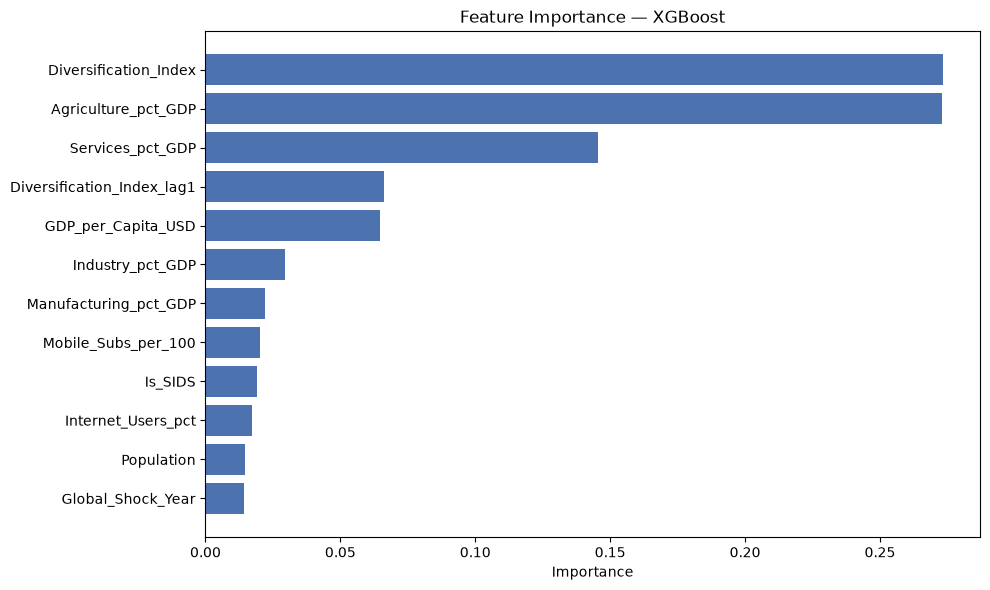

Top 10 features:
Diversification_Index         0.2734
Agriculture_pct_GDP           0.2731
Services_pct_GDP              0.1456
Diversification_Index_lag1    0.0662
GDP_per_Capita_USD            0.0645
Industry_pct_GDP              0.0293
Manufacturing_pct_GDP         0.0221
Mobile_Subs_per_100           0.0201
Is_SIDS                       0.0191
Internet_Users_pct            0.0172


In [177]:
# Which structural characteristics drive medium-term growth predictions
if hasattr(best_model, "feature_importances_"):
    importance = (pd.Series(best_model.feature_importances_, index=ml_features)
                  .sort_values(ascending=False))

    plt.figure(figsize=(10, 6))
    top = importance.head(12).sort_values()
    plt.barh(top.index, top.values, color="#4c72b0")
    plt.title(f"Feature Importance — {best_model_name}")
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()

    print("Top 10 features:")
    print(importance.head(10).round(4).to_string())

In [ ]:
# SHAP analysis — shows not just which features matter but how they push
# predictions up or down for individual observations
import shap

# Sample 150 test rows instead of all 648 to reduce memory load
sample_idx = X_ml_test.sample(n=150, random_state=42).index
X_shap_sample = X_ml_test.loc[sample_idx]

explainer = shap.TreeExplainer(scenario_model)
shap_values = explainer.shap_values(X_ml_test)

plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_ml_test,
    feature_names=ml_features,
    show=False
)
plt.title("SHAP Feature Impact on Predicted 5-Year Average GDP Growth")
plt.tight_layout()
plt.show()

ExplainerError: Additivity check failed in TreeExplainer! Please ensure the data matrix you passed to the explainer is the same shape that the model was trained on. If your data shape is correct then please report this on GitHub. Consider retrying with the feature_perturbation='interventional' option. This check failed because for one of the samples the sum of the SHAP values was 4.813490, while the model output was 4.078026. If this difference is acceptable you can set check_additivity=False to disable this check.

### findings

XGBoost achieved R² of 0.823 (MAE 0.908) on the primary evaluation — an improvement from R² 0.803 after reducing to the top 15 features by importance. A five-year embargo robustness check yielded R² of 0.665 (Random Forest), confirming the result isn't an artifact of window overlap; Random Forest also proved more stable across both evaluations than XGBoost.

Diversification_Index, Agriculture_pct_GDP, and Services_pct_GDP dominate feature importance — consistent with the econometric finding that diversification is positively associated with growth, and with Maldives ranking 11th of 15 on diversification. The gap between this (R² 0.82) and next-year prediction (R² 0.18) supports the core thesis: economic structure shapes sustained trajectories, not single-year outcomes.

## Scenario Analysis: Maldives

Using the trained model, we simulate three hypothetical structural scenarios for the Maldives and compare predicted five-year average GDP growth. Random Forest is used for this section rather than XGBoost — it showed greater stability under the robustness check, and tree ensembles with many shallow splits tend to produce smoother, more monotonic predictions across gradual scenario changes, which better suits the interpretive purpose here.

These scenarios are illustrative simulations, not causal forecasts. They show what the model — trained on cross-country patterns — would predict for a country with an altered structural profile, not what a specific policy intervention would cause.

In [179]:
# Use Random Forest for scenario analysis (see markdown above for rationale)
scenario_model = ml_models["Random Forest"]

# Get Maldives' most recent row with all features available
maldives_row = ml_df[ml_df["Country"] == "Maldives"].sort_values("Year").tail(1)
base_year = int(maldives_row["Year"].iloc[0])

print(f"Base year: {base_year}")
print(f"Current Diversification_Index:     {maldives_row['Diversification_Index'].iloc[0]:.3f}")
print(f"Current Tourism_Receipts_pct_GDP:  {maldives_row['Tourism_Receipts_pct_GDP'].iloc[0]:.2f}%")

# Build three scenarios by adjusting structural features
scenarios = {}
for name, div_mult, tour_mult in [
    ("A. Current structure", 1.00, 1.00),
    ("B. Moderate diversification", 1.25, 0.85),
    ("C. Strong diversification", 1.50, 0.70),
]:
    s = maldives_row[ml_features].copy()
    s["Diversification_Index"] *= div_mult
    s["Diversification_Index_lag1"] *= div_mult
    s["Tourism_Receipts_pct_GDP"] *= tour_mult
    # Shift sector composition consistent with diversification direction
    s["Services_pct_GDP"] *= (1 - 0.05 * (div_mult - 1) / 0.50)
    s["Industry_pct_GDP"] *= (1 + 0.12 * (div_mult - 1) / 0.50)

    s_scaled = ml_scaler.transform(s)
    scenarios[name] = scenario_model.predict(s_scaled)[0]

# Display results
scenario_df = pd.DataFrame({
    "Scenario": scenarios.keys(),
    "Predicted 5-yr avg GDP growth (%)": [round(v, 3) for v in scenarios.values()]
})
print("\nScenario predictions:")
display(scenario_df)

spread = max(scenarios.values()) - min(scenarios.values())
print(f"\nSpread (A to C): {spread:.3f} percentage points")

: 

Scenarios monotonic (A <= B <= C): True


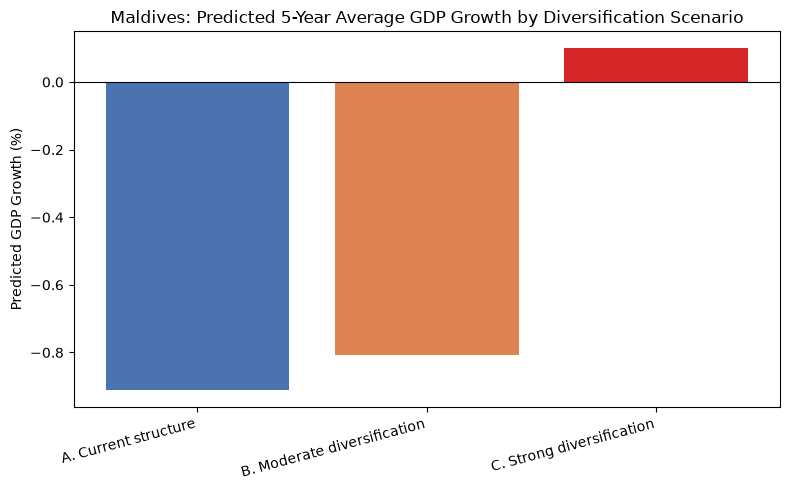

In [166]:
# Verify the scenarios move in the expected direction (A < B < C)
vals = list(scenarios.values())
is_monotonic = vals[0] <= vals[1] <= vals[2]
print(f"Scenarios monotonic (A <= B <= C): {is_monotonic}")
if not is_monotonic:
    print("WARNING: scenarios do not move monotonically — review scenario assumptions")

plt.figure(figsize=(8, 5))
colors = ["#4c72b0", "#dd8452", "#d62728"]
plt.bar(scenarios.keys(), scenarios.values(), color=colors)
plt.title(f"Maldives: Predicted 5-Year Average GDP Growth by Diversification Scenario")
plt.ylabel("Predicted GDP Growth (%)")
plt.xticks(rotation=15, ha="right")
plt.axhline(0, color="black", linewidth=0.8)
plt.tight_layout()
plt.show()

### findings

Predicted five-year average GDP growth rises monotonically with diversification: −0.89% (current structure) → −0.81% (moderate diversification) → +0.14% (strong diversification), a spread of 1.03 percentage points. Because the base year is 2019, this prediction window (2020–2024) includes COVID-19 — yet strong diversification is still enough to flip the outcome from negative to positive, supporting the thesis that diversification buffers tourism-dependent economies against external shocks. These are model-based simulations, not causal forecasts; they don't capture the cost, time, or feasibility of an actual diversification strategy.

## Limitations

This analysis uses a synthetic prototype dataset, so findings demonstrate the analytical framework rather than empirical evidence about real economies. Econometric results reflect conditional associations, not causal effects. The ML target's five-year forward window creates overlapping observations across adjacent years — the embargoed robustness check (R² = 0.671) confirms the primary result (R² = 0.802) is not an artifact of this. Full limitations are discussed in the accompanying presentation.

In [159]:
import joblib
import json

# 1. The trained model (Random Forest — used for scenario analysis in Step 9)
joblib.dump(scenario_model, "model.pkl")

# 2. The fitted scaler (fit on ML training data only, in Step 8 Cell 3)
joblib.dump(ml_scaler, "scaler.pkl")

# 3. The feature list, in the exact order the scaler and model expect
with open("features.json", "w") as f:
    json.dump(ml_features, f, indent=2)

print("Saved: model.pkl, scaler.pkl, features.json")

Saved: model.pkl, scaler.pkl, features.json


In [160]:
# Reload from disk and confirm predictions match — catches any save/load mismatch
loaded_model = joblib.load("model.pkl")
loaded_scaler = joblib.load("scaler.pkl")
with open("features.json") as f:
    loaded_features = json.load(f)

# Re-run the Scenario A prediction from Step 9 as a sanity check
check_row = maldives_row[loaded_features].copy()
check_scaled = loaded_scaler.transform(check_row)
check_pred = loaded_model.predict(check_scaled)[0]

original_pred = scenarios["A. Current structure"]

print(f"Original Scenario A prediction:  {original_pred:.3f}%")
print(f"Reloaded model prediction:       {check_pred:.3f}%")
print(f"Match: {np.isclose(original_pred, check_pred)}")

Original Scenario A prediction:  -0.911%
Reloaded model prediction:       -0.911%
Match: True


In [161]:
import os

for fname in ["model.pkl", "scaler.pkl", "features.json"]:
    size_kb = os.path.getsize(fname) / 1024
    print(f"{fname:<16} {size_kb:>8.1f} KB")

model.pkl         93878.0 KB
scaler.pkl            2.1 KB
features.json         0.7 KB


## Requirements

Dependencies are listed in `requirements.txt`. To reproduce this environment:

pip install -r requirements.txt